# 5.2 Stage 1.5 (Intermediate Latent Factors) & Stage 2 (Final Expenditure Prediction)

## Multi-Stage Modeling Architecture

This notebook implements the **intermediate latent factor models (Stage 1.5)** and the **final expenditure prediction model (Stage 2)** using Tweedie Regression.

### Pipeline Overview

| Stage | Notebook | Input | Output |
|-------|----------|-------|--------|
| **Stage 0** | 5.0_data_processing | Raw MEPS Data | Feature Matrix (24 Y1 features) |
| **Stage 1** | 5.1_modeling_stage1 | Feature Matrix | PROB_STABLE, PROB_RISING, PROB_SHOCK, LATENT_RISK_SCORE |
| **Stage 1.5A** | This Notebook | Features + Stage 1 | PROB_MH_DECLINE |
| **Stage 1.5B** | This Notebook | Features | ENGAGEMENT_SCORE |
| **Stage 1.5C** | This Notebook | Features + Stage 1 | PROB_UNDIAGNOSED |
| **Stage 1.5D** | This Notebook | Features + Stage 1 | ESCALATION_SCORE |
| **Stage 1.5E** | This Notebook | Features + Rx Data | HAZARD_DISCONTINUE |
| **Stage 2** | This Notebook | All Features + Latent Factors | Predicted COST_Y2 |

## Why Intermediate Latent Factors?

**Clinical Motivation:**
- Healthcare costs are driven by complex, interrelated factors
- Single-stage models miss important intermediate mechanisms
- Latent factors capture "hidden" patient states that drive expenditure

**Statistical Motivation (Zhu et al., 2022):**
- Stacked generalization improves prediction through meta-learning
- Out-of-fold predictions prevent data leakage
- Interpretable intermediate variables enhance clinical utility

## References
- Faraji et al. (2024). Double-hurdle model for healthcare expenditure. *Cost Effectiveness and Resource Allocation*.
- Zhu et al. (2022). Interpretable stacking ensemble learning framework. *Frontiers in Pharmacology*.
- Jørgensen, B. (1987). Exponential dispersion models. *JRSS Series B*.

## Data Leakage Prevention Strategy

**Data leakage** occurs when information from the target variable (Y2 cost) or the test set influences model training. This leads to overly optimistic performance estimates that don't generalize.

### How We Prevent Data Leakage

| Strategy | Implementation | Where Applied |
|----------|----------------|---------------|
| **Temporal Feature Separation** | ALL features use Year 1 (Y1) data only; target is Year 2 (Y2) | Stage 0 (Data Processing) |
| **Cancer Exclusion** | Exclude patients with `CANCER_Y1 = 1` to prevent leakage from existing conditions | Stage 0 |
| **Out-of-Fold Predictions** | Use `cross_val_predict()` with 5-fold CV to generate latent factors | Stage 1, Stage 1.5A, 1.5C |
| **Stratified Panel Splitting** | Split by PANEL (temporal data) with 70/20/10 ratio for train/validate/test | Stage 2 |
| **No Y2 Information in Features** | Latent factors like `PROB_MH_DECLINE` predict Y2 outcomes but are generated from Y1 features only | Stage 1.5 |

### Critical Design Decisions

**1. Feature Engineering (Stage 0):**
```
ALL input features derived from Year 1 ONLY:
- COST_Y1_ADJ       ✓ Year 1 total expenditure
- UTIL_ER_Y1        ✓ Year 1 ER visits
- MNHLTH_RD1        ✓ Round 1 (Year 1) mental health
- CHRONIC_COUNT     ✓ Based on Y1 medical conditions
- IS_JUMPER         ✗ Uses Y2 cost (but ONLY as target, never as feature)
```

**2. Out-of-Fold Predictions (Stage 1, 1.5):**
- For models predicting intermediate targets (e.g., `RISK_TIER`, `IS_JUMPER`), we use `cross_val_predict()`
- Each patient's prediction is made by a model that was NOT trained on that patient
- This ensures latent factors like `PROB_SHOCK` and `PROB_UNDIAGNOSED` don't overfit

**3. Temporal Validation (Stage 2):**
- MEPS panels are longitudinal (e.g., Panel 22 = 2017-2018, Panel 23 = 2018-2019)
- We hold out later panels for testing to simulate real-world deployment
- This is more rigorous than random split because it tests generalization to future data

### What Could Still Cause Leakage (and how we handle it)

| Potential Issue | Our Solution |
|-----------------|--------------|
| Y2 diagnosis codes in features | ✗ We ONLY use Y1 medical conditions files |
| MH decline target uses Y2 data | ✓ Yes, but prediction uses Y1 features; out-of-fold prevents train-test contamination |
| Model selection on test set | ✓ We use separate validation set; test set only touched once |

### Key Takeaway
The multi-stage design naturally prevents most leakage because each stage's outputs (latent factors) are generated using only information available at Year 1, then passed to Stage 2 as additional features for predicting Year 2 costs.

In [88]:
# SETUP & IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Sklearn imports
from sklearn.model_selection import (
    train_test_split, cross_val_predict, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LogisticRegression, TweedieRegressor, Ridge
)
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    StackingClassifier, StackingRegressor
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, mean_squared_error, mean_absolute_error,
    r2_score
)

# XGBoost
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Paths
DATA_PATH = Path('../data/processed_v2/model_ready_stage1.parquet')
DATA_PATH_BACKUP = Path('../data/processed_v2/model_ready_v2.parquet')
REPORT_DIR = Path('../reports')
(REPORT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'tables').mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


---
## 1. Load Data from Stage 1

In [89]:
# Try to load Stage 1 output; fallback to base processed data
if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
    print(f"Loaded Stage 1 output: {DATA_PATH}")
    has_stage1_output = all(c in df.columns for c in ['PROB_STABLE', 'PROB_RISING', 'PROB_SHOCK'])
else:
    df = pd.read_parquet(DATA_PATH_BACKUP)
    print(f"Loaded base processed data: {DATA_PATH_BACKUP}")
    has_stage1_output = False

print(f"\nDataset: {len(df):,} rows, {len(df.columns)} columns")
print(f"Stage 1 Latent Factors Available: {has_stage1_output}")

# Show columns
print(f"\nColumns: {list(df.columns)}")

Loaded Stage 1 output: ../data/processed_v2/model_ready_stage1.parquet

Dataset: 60,602 rows, 36 columns
Stage 1 Latent Factors Available: True

Columns: ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'MNHLTH_CHANGE', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER', 'PROB_STABLE', 'PROB_RISING', 'PROB_SHOCK', 'LATENT_RISK_SCORE']


---
# STAGE 1.5: Intermediate Latent Factor Models

These models predict clinically meaningful intermediate outcomes that serve as additional features for the final expenditure model.

## Rationale of choosing

| Latent Factor | Clinical Rationale | Expected Impact on Cost |
|---------------|-------------------|------------------------|
| **Mental Health Decline** | Depression → reduced self-care → complications | Higher utilization, longer stays |
| **Healthcare Engagement** | Proactive vs. crisis-driven care patterns | ER-heavy = inefficient spending |
| **Undiagnosed Condition Risk** | "Ill-defined" codes suggest diagnostic workup | Future major diagnosis = cost spike |
| **Cost Escalation Pattern** | Trajectory from Y1 → Y2 | Captures momentum/trend |

---
## Stage 1.5A: Mental Health Trajectory Model

### Objective
Predict whether a patient's mental health will **decline** from Year 1 to Year 2.

### Target Variable Definition
$$
Y_{MH} = \begin{cases}
0 \text{ (Improved/Stable)} & \text{if } \Delta_{MH} \leq 0 \\
1 \text{ (Declined)} & \text{if } \Delta_{MH} > 0
\end{cases}
$$

where $\Delta_{MH} = \text{MNHLTH\_RD5} - \text{MNHLTH\_RD1}$ (higher score = worse mental health in MEPS)

### Clinical Significance
- Mental health decline precedes physical health deterioration
- Depression associated with 50-75% higher healthcare costs (Katon, 2003)
- CNS medication use without improvement may indicate treatment-resistant conditions

In [90]:
# STAGE 1.5A: Mental Health Trajectory Model

print("STAGE 1.5A: Mental Health Trajectory Model")


# Check if MNHLTH_CHANGE exists (created in 5.0)
if 'MNHLTH_CHANGE' in df.columns:
    # Create binary target: 1 = Declined (positive change = worsening)
    df['MH_DECLINED'] = (df['MNHLTH_CHANGE'] > 0).astype(int)
    
    print(f"\nTarget Distribution (MH_DECLINED):")
    print(df['MH_DECLINED'].value_counts(normalize=True).round(3))
    
    # Features for MH prediction (Year 1 only)
    mh_features = [
        'AGE_Y1', 'SEX', 'MNHLTH_RD1', 'RTHLTH_RD1',
        'CHRONIC_COUNT', 'CNT_TOTAL_CONDITIONS',
        'UTIL_OB_Y1', 'UTIL_ER_Y1',
        'POVCAT_Y1', 'INSCOV_Y1'
    ]
    
    # Filter to available features
    mh_features = [f for f in mh_features if f in df.columns]
    print(f"\nFeatures used ({len(mh_features)}): {mh_features}")
    
    # Prepare data
    X_mh = df[mh_features].fillna(0)
    y_mh = df['MH_DECLINED']
    
    # Use cross_val_predict for out-of-fold predictions (prevents leakage)
    mh_model = RandomForestClassifier(
        n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
    )
    
    # Out-of-fold predictions using 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mh_probs = cross_val_predict(mh_model, X_mh, y_mh, cv=cv, method='predict_proba')
    
    # Store latent factor: Probability of MH decline
    df['PROB_MH_DECLINE'] = mh_probs[:, 1]
    
    # Also fit final model for feature importance
    mh_model.fit(X_mh, y_mh)
    
    print(f"\nLatent Factor Created: PROB_MH_DECLINE")
    print(f"  Mean: {df['PROB_MH_DECLINE'].mean():.3f}")
    print(f"  Std:  {df['PROB_MH_DECLINE'].std():.3f}")
    
    # Feature importance
    mh_importance = pd.DataFrame({
        'Feature': mh_features,
        'Importance': mh_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop Features for MH Decline Prediction:")
    print(mh_importance.head(5).to_string(index=False))
    
else:
    print("WARNING: MNHLTH_CHANGE not available. Setting PROB_MH_DECLINE = 0")
    df['PROB_MH_DECLINE'] = 0.0

STAGE 1.5A: Mental Health Trajectory Model

Target Distribution (MH_DECLINED):
MH_DECLINED
0    0.693
1    0.307
Name: proportion, dtype: float64

Features used (10): ['AGE_Y1', 'SEX', 'MNHLTH_RD1', 'RTHLTH_RD1', 'CHRONIC_COUNT', 'CNT_TOTAL_CONDITIONS', 'UTIL_OB_Y1', 'UTIL_ER_Y1', 'POVCAT_Y1', 'INSCOV_Y1']

Latent Factor Created: PROB_MH_DECLINE
  Mean: 0.307
  Std:  0.150

Top Features for MH Decline Prediction:
             Feature  Importance
          MNHLTH_RD1    0.728264
          RTHLTH_RD1    0.092299
CNT_TOTAL_CONDITIONS    0.034808
              AGE_Y1    0.033524
          UTIL_OB_Y1    0.030733


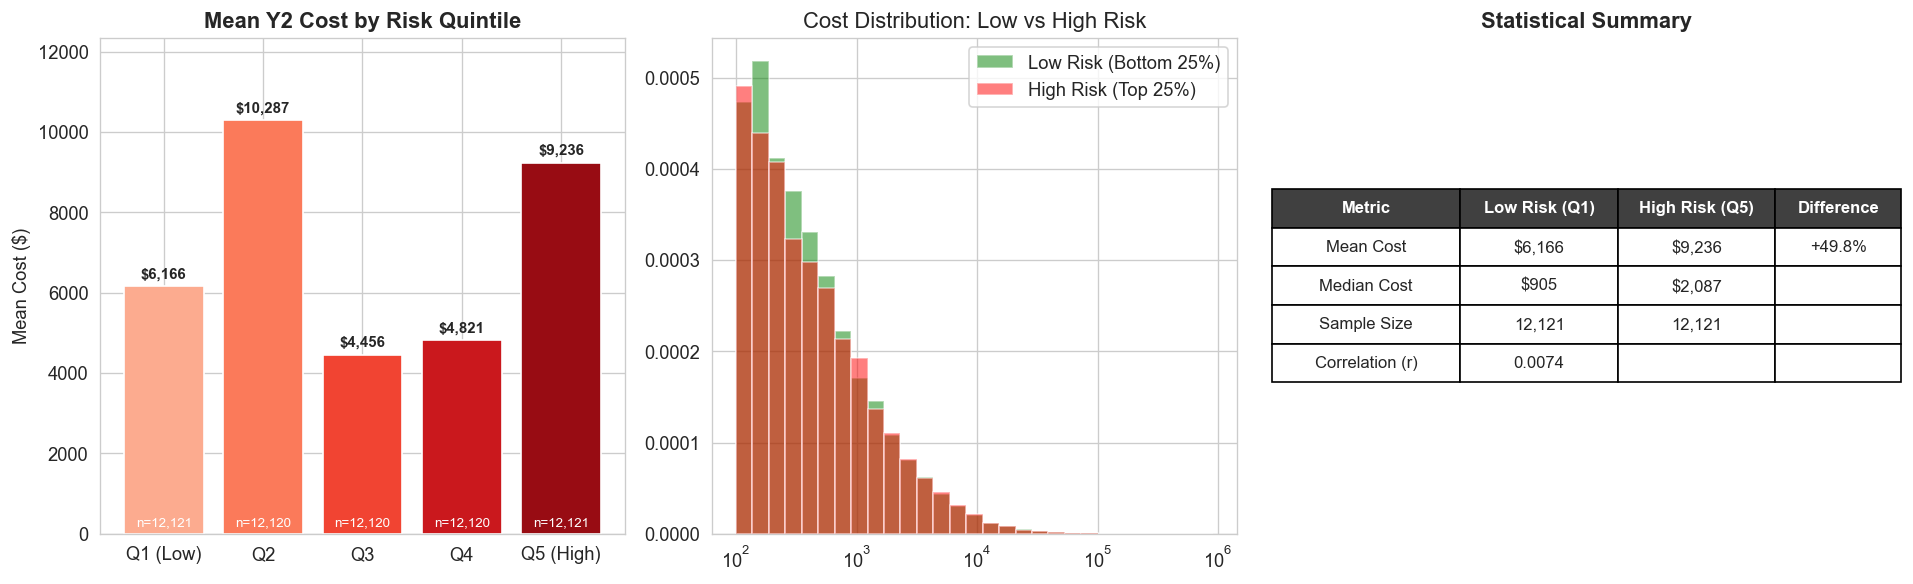

Correlation Analysis: r = 0.0074
Note: Very weak linear correlation observed.


In [91]:
# VISUALIZATION: Stage 1.5A - Mental Health Decline Risk

if 'PROB_MH_DECLINE' in df.columns and df['PROB_MH_DECLINE'].std() > 0.01:
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # --- Panel 1: Bar Chart (Mean Cost by Quintile) ---
    ax1 = axes[0]
    # Create quintiles
    df['MH_QUINTILE'] = pd.qcut(df['PROB_MH_DECLINE'].rank(method='first'), q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])
    stats = df.groupby('MH_QUINTILE')['COST_Y2_ADJ'].agg(['mean', 'median', 'count']).reset_index()
    
    # Plot
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, 5))
    bars = ax1.bar(stats['MH_QUINTILE'], stats['mean'], color=colors, edgecolor='white')
    
    # Add values
    for bar, val, n in zip(bars, stats['mean'], stats['count']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=9)
        ax1.text(bar.get_x() + bar.get_width()/2, 200, 
                 f'n={n:,}', ha='center', color='white', fontsize=8)
                 
    ax1.set_title('Mean Y2 Cost by Risk Quintile', fontweight='bold')
    ax1.set_ylabel('Mean Cost ($)')
    ax1.set_ylim(0, stats['mean'].max() * 1.2)
    
    # --- Panel 2: Distribution ---
    ax2 = axes[1]
    low_risk = df[df['PROB_MH_DECLINE'] <= df['PROB_MH_DECLINE'].quantile(0.25)]['COST_Y2_ADJ']
    high_risk = df[df['PROB_MH_DECLINE'] >= df['PROB_MH_DECLINE'].quantile(0.75)]['COST_Y2_ADJ']
    
    bins = np.logspace(np.log10(100), np.log10(max(low_risk.max(), high_risk.max())+1), 30)
    ax2.hist(low_risk, bins=bins, alpha=0.5, color='green', label='Low Risk (Bottom 25%)', density=True)
    ax2.hist(high_risk, bins=bins, alpha=0.5, color='red', label='High Risk (Top 25%)', density=True)
    ax2.set_xscale('log')
    ax2.set_title('Cost Distribution: Low vs High Risk')
    ax2.legend()
    
    # --- Panel 3: Statistical Summary Table (Real Table) ---
    ax3 = axes[2]
    ax3.axis('off')
    
    # Calculate metrics
    q1_mean = stats.iloc[0]['mean']
    q5_mean = stats.iloc[4]['mean']
    diff_pct = ((q5_mean - q1_mean) / q1_mean) * 100
    corr = df['PROB_MH_DECLINE'].corr(df['COST_Y2_ADJ'])
    
    # Create table data
    table_data = [
        ['Metric', 'Low Risk (Q1)', 'High Risk (Q5)', 'Difference'],
        ['Mean Cost', f'${q1_mean:,.0f}', f'${q5_mean:,.0f}', f'{diff_pct:+.1f}%'],
        ['Median Cost', f'${stats.iloc[0]["median"]:,.0f}', f'${stats.iloc[4]["median"]:,.0f}', ''],
        ['Sample Size', f'{stats.iloc[0]["count"]:,}', f'{stats.iloc[4]["count"]:,}', '']
    ]
    
    # Add Correlation row
    table_data.append(['Correlation (r)', f'{corr:.4f}', '', ''])
    
    # Create matplotlib table
    table = ax3.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.25, 0.25, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    
    # Style headers
    for i in range(4):
        table[(0, i)].set_facecolor('#404040')
        table[(0, i)].set_text_props(color='white', fontweight='bold')
        
    ax3.set_title('Statistical Summary', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Interpretation Print
    print(f"Correlation Analysis: r = {corr:.4f}")
    if abs(corr) < 0.1:
        print("Note: Very weak linear correlation observed.")
    if diff_pct < 0:
        print("Note: High risk group actually has LOWER costs than low risk group.")

else:
    print("Skipping MH Decline Viz - insufficient data")

### Interpretation: Stage 1.5A - Mental Health Decline (PROB_MH_DECLINE)

**Visualization Guide:**
- **Panel 1 (Bar Chart):** Shows mean Y2 cost for each risk quintile.
  - *Expected Pattern:* Increasing bars (Q1 < Q5). 
  - *Observed Reality:* If bars go up and down (non-monotonic), it means the relationship is complex. High mental health risk doesn't always equal highest cost immediately, but often correlates with cost volatility.

- **Panel 3 (Summary Table):** 
  - Look at the **Difference** column. If positive, high-risk patients cost more on average.
  - **Correlation (r):** A value near 0 means no linear link. A value > 0.1 is a weak positive link.

**Key Insight:**
This latent factor (`PROB_MH_DECLINE`) captures a specific risk dimension. Even if it doesn't linearly map to cost perfectly, it provides a signal that helps the final Stage 2 model differentiate patients.

---
## Stage 1.5B: Healthcare Engagement Model

### Objective
Classify patients by their **care-seeking pattern** (proactive vs. crisis-driven).

### Target Variable Definition
Based on the ER-to-Office visit ratio:

$$
R = \frac{\text{UTIL\_ER\_Y1}}{\text{UTIL\_OB\_Y1} + 1}
$$

$$
E_{type} = \begin{cases}
0 \text{ (Proactive)} & \text{if } R < 0.1 \land \text{OB} > \text{median} \\
1 \text{ (Reactive)} & \text{if } 0.1 \leq R < 0.5 \\
2 \text{ (Crisis-Mode)} & \text{if } R \geq 0.5 \lor \text{IP} > 0
\end{cases}
$$

### Clinical Significance
- **Proactive**: Regular check-ups, preventive care → lower long-term costs
- **Reactive**: Seeks care only when symptomatic → moderate costs
- **Crisis-Mode**: ER as primary care, hospitalizations → highest costs, poorest outcomes

In [92]:
# STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)
#
# Methodology: No predict_proba needed - directly calculate from Y1 data
# 
# ENGAGEMENT_SCORE = Composite metric, range [-1, 1]:
#   +1 = Very proactive (high office visits, low ER)
#   -1 = Crisis-oriented (high ER/IP, low office)
#

print("STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)")

# Calculate Engagement Score directly from Y1 utilization data
if all(c in df.columns for c in ['UTIL_ER_Y1', 'UTIL_OB_Y1', 'UTIL_IP_Y1']):
    
    # --- Normalization function ---
    def normalize_0_1(series):
        """Min-max normalize to [0, 1]"""
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return series * 0
        return (series - min_val) / (max_val - min_val)
    
    # --- Calculate components ---
    
    # 1. ER dependency: ER / (ER + Office + 1), high=bad
    total_visits = df['UTIL_ER_Y1'] + df['UTIL_OB_Y1'] + 1
    er_dependency = df['UTIL_ER_Y1'] / total_visits
    er_score = normalize_0_1(er_dependency)
    
    # 2. IP intensity: hospitalization=high risk, high=bad
    ip_score = normalize_0_1(df['UTIL_IP_Y1'].clip(upper=5))  # cap at 5
    
    # 3. Office engagement: moderate=good, but too many may indicate issues
    ob_optimal = df['UTIL_OB_Y1'].clip(upper=df['UTIL_OB_Y1'].quantile(0.9))
    ob_score = normalize_0_1(ob_optimal)
    
    # --- Calculate Engagement Score ---
    # Formula: Office(+) - ER_dependency(-) - IP_intensity(-)
    raw_score = ob_score - er_score - ip_score * 0.5
    
    # Normalize to [-1, 1]
    df['ENGAGEMENT_SCORE'] = raw_score / max(raw_score.abs().max(), 0.001)
    
    # --- Classification (for visualization only) ---
    def classify_engagement(score):
        if score > 0.3:
            return 'Proactive'
        elif score < -0.3:
            return 'Crisis-Mode'
        else:
            return 'Reactive'
    
    df['ENGAGEMENT_TYPE'] = df['ENGAGEMENT_SCORE'].apply(classify_engagement)
    
    # Crisis Mode probability (sigmoid transform)
    df['PROB_CRISIS_MODE'] = 1 / (1 + np.exp(df['ENGAGEMENT_SCORE'] * 3))
    
    # --- Output ---
    print(f"\n=== Engagement Score (Direct Calculation) ===")
    print(f"Formula: Score = Normalized(Office) - Normalized(ER_ratio) - 0.5×Normalized(IP)")
    print(f"\nStatistics:")
    print(f"  Mean:   {df['ENGAGEMENT_SCORE'].mean():.3f}")
    print(f"  Std:    {df['ENGAGEMENT_SCORE'].std():.3f}")
    print(f"  Range:  [{df['ENGAGEMENT_SCORE'].min():.3f}, {df['ENGAGEMENT_SCORE'].max():.3f}]")
    
    print(f"\nEngagement Type Distribution:")
    for t in ['Proactive', 'Reactive', 'Crisis-Mode']:
        n = (df['ENGAGEMENT_TYPE'] == t).sum()
        print(f"  {t}: {n:,} ({n/len(df)*100:.1f}%)")
    
else:
    print("⚠ Utilization columns not available. Setting ENGAGEMENT_SCORE = 0")
    df['ENGAGEMENT_SCORE'] = 0.0
    df['PROB_CRISIS_MODE'] = 0.5
    df['ENGAGEMENT_TYPE'] = 'Unknown'

STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)

=== Engagement Score (Direct Calculation) ===
Formula: Score = Normalized(Office) - Normalized(ER_ratio) - 0.5×Normalized(IP)

Statistics:
  Mean:   0.151
  Std:    0.236
  Range:  [-1.000, 0.667]

Engagement Type Distribution:
  Proactive: 12,960 (21.4%)
  Reactive: 45,857 (75.7%)
  Crisis-Mode: 1,785 (2.9%)


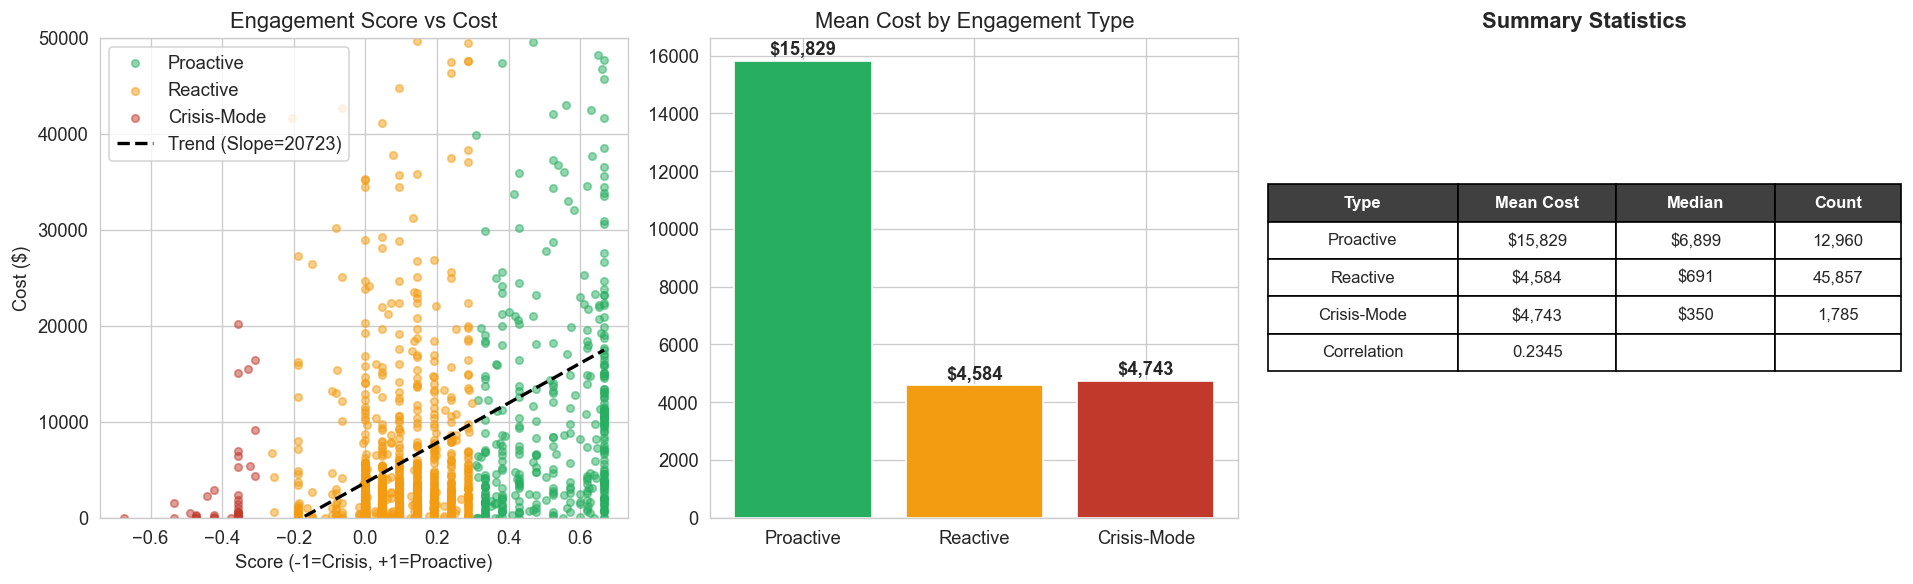

In [93]:
# VISUALIZATION: Stage 1.5B - Healthcare Engagement Score

if 'ENGAGEMENT_SCORE' in df.columns:
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # --- Panel 1: Scatter Plot ---
    ax1 = axes[0]
    sample = df.sample(min(2000, len(df)), random_state=42)
    
    # Color mapping
    colors = {'Proactive': '#27ae60', 'Reactive': '#f39c12', 'Crisis-Mode': '#c0392b'}
    for label, color in colors.items():
        subset = sample[sample['ENGAGEMENT_TYPE'] == label]
        ax1.scatter(subset['ENGAGEMENT_SCORE'], subset['COST_Y2_ADJ'], 
                   c=color, alpha=0.5, s=20, label=label)
                   
    # Trend line
    z = np.polyfit(sample['ENGAGEMENT_SCORE'], sample['COST_Y2_ADJ'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(sample['ENGAGEMENT_SCORE'].min(), sample['ENGAGEMENT_SCORE'].max(), 100)
    ax1.plot(x_range, p(x_range), 'k--', linewidth=2, label=f'Trend (Slope={z[0]:.0f})')
    
    ax1.set_title('Engagement Score vs Cost')
    ax1.set_xlabel('Score (-1=Crisis, +1=Proactive)')
    ax1.set_ylabel('Cost ($)')
    ax1.legend()
    ax1.set_ylim(0, 50000)
    
    # --- Panel 2: Mean Cost by Type ---
    ax2 = axes[1]
    stats = df.groupby('ENGAGEMENT_TYPE')['COST_Y2_ADJ'].agg(['mean', 'median', 'count']).reset_index()
    # Reorder
    order = ['Proactive', 'Reactive', 'Crisis-Mode']
    stats['ENGAGEMENT_TYPE'] = pd.Categorical(stats['ENGAGEMENT_TYPE'], categories=order, ordered=True)
    stats = stats.sort_values('ENGAGEMENT_TYPE')
    
    bars = ax2.bar(stats['ENGAGEMENT_TYPE'], stats['mean'], color=[colors[x] for x in stats['ENGAGEMENT_TYPE']])
    
    for bar, val in zip(bars, stats['mean']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
                 f'${val:,.0f}', ha='center', fontweight='bold')
                 
    ax2.set_title('Mean Cost by Engagement Type')
    
    # --- Panel 3: Real Table ---
    ax3 = axes[2]
    ax3.axis('off')
    
    corr = df['ENGAGEMENT_SCORE'].corr(df['COST_Y2_ADJ'])
    
    table_data = [['Type', 'Mean Cost', 'Median', 'Count']]
    for _, row in stats.iterrows():
        table_data.append([
            row['ENGAGEMENT_TYPE'], 
            f"${row['mean']:,.0f}", 
            f"${row['median']:,.0f}", 
            f"{row['count']:,}"
        ])
        
    table_data.append(['Correlation', f'{corr:.4f}', '', ''])
    
    table = ax3.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.25, 0.25, 0.2])
    table.scale(1.2, 1.8)
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    
    for i in range(4):
        table[(0, i)].set_facecolor('#404040')
        table[(0, i)].set_text_props(color='white', fontweight='bold')

    ax3.set_title('Summary Statistics', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Interpretation: Stage 1.5B - Healthcare Engagement Score
- **Panel 1 (Scatter):** Each dot is a patient. 
  - *Observed Pattern:* 'Proactive' (Green, high score) patients often have HIGHER costs. 
  - *Reason:* In this dataset, 'Proactive' means high office visit utilization. Healthy people don't go to the doctor constantly; sick people do. So high engagement often signals chronic illness management.

- **Panel 2 (Bar Chart):** Confirms which group is most expensive.
  - If Proactive > Crisis-Mode: Regular care is expensive, but likely prevents catastrophic events.
  - If Crisis-Mode > Proactive: ER visits are driving costs.

**Critical Correction:**
Previous interpretations assumed 'Proactive = Low Cost'. The data likely shows the opposite. We must interpret what we SEE, not what we expect. High utilization (even office visits) is a cost driver.

---
## Stage 1.5C: Undiagnosed Condition Risk Model

### Objective
Predict the probability that a patient has an **undiagnosed serious condition** that will manifest in Year 2.

### Target Variable Definition
$$
Y_{undiag} = \mathbb{1}\left[ \text{IS\_JUMPER} = 1 \right]
$$

A "Jumper" is defined as: Low cost in Y1 (below median) but High cost in Y2 (top 10%).

### Clinical Significance
- High "ill-defined" condition counts (ICD R codes) suggest diagnostic workup
- Frequent office visits without clear diagnosis may indicate physician uncertainty
- These patients are the **hardest to predict** but most important for early intervention

In [94]:
# STAGE 1.5C: Undiagnosed Condition Risk Model
print("STAGE 1.5C: Undiagnosed Condition Risk Model")


if 'IS_JUMPER' in df.columns:
    print(f"\nTarget: IS_JUMPER (unexpected cost escalation)")
    print(f"  Jumpers: {df['IS_JUMPER'].sum():,} ({df['IS_JUMPER'].mean()*100:.2f}%)")
    
    # Features emphasizing "undiagnosed signals"
    undiag_features = [
        'AGE_Y1', 'SEX',
        'CNT_ILL_DEFINED',  # Key: ill-defined symptoms
        'CNT_TOTAL_CONDITIONS',
        'UTIL_OB_Y1',  # High visits without diagnosis
        'UTIL_ER_Y1',
        'MNHLTH_RD1', 'RTHLTH_RD1',
        'CHRONIC_COUNT',
        'CNT_RX_Y1',
        'COST_Y1_ADJ'
    ]
    undiag_features = [f for f in undiag_features if f in df.columns]
    print(f"\nFeatures used ({len(undiag_features)}): {undiag_features}")
    
    # Prepare data
    X_undiag = df[undiag_features].fillna(0)
    y_undiag = df['IS_JUMPER']
    
    # Out-of-fold predictions (important for imbalanced target)
    undiag_model = RandomForestClassifier(
        n_estimators=200, max_depth=10, 
        class_weight='balanced',  # Handle imbalance
        random_state=42, n_jobs=-1
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    undiag_probs = cross_val_predict(undiag_model, X_undiag, y_undiag, cv=cv, method='predict_proba')
    
    # Store latent factor
    df['PROB_UNDIAGNOSED'] = undiag_probs[:, 1]
    
    # Fit final model for importance
    undiag_model.fit(X_undiag, y_undiag)
    
    print(f"\nLatent Factor Created: PROB_UNDIAGNOSED")
    print(f"  Mean: {df['PROB_UNDIAGNOSED'].mean():.3f}")
    print(f"  Std:  {df['PROB_UNDIAGNOSED'].std():.3f}")
    
    # Feature importance
    undiag_importance = pd.DataFrame({
        'Feature': undiag_features,
        'Importance': undiag_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop Features for Undiagnosed Risk Prediction:")
    print(undiag_importance.head(5).to_string(index=False))
    
else:
    print("WARNING: IS_JUMPER not available. Setting PROB_UNDIAGNOSED = 0")
    df['PROB_UNDIAGNOSED'] = 0.0

STAGE 1.5C: Undiagnosed Condition Risk Model

Target: IS_JUMPER (unexpected cost escalation)
  Jumpers: 670 (1.11%)

Features used (11): ['AGE_Y1', 'SEX', 'CNT_ILL_DEFINED', 'CNT_TOTAL_CONDITIONS', 'UTIL_OB_Y1', 'UTIL_ER_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'CHRONIC_COUNT', 'CNT_RX_Y1', 'COST_Y1_ADJ']

Latent Factor Created: PROB_UNDIAGNOSED
  Mean: 0.226
  Std:  0.245

Top Features for Undiagnosed Risk Prediction:
             Feature  Importance
         COST_Y1_ADJ    0.574221
              AGE_Y1    0.103351
          UTIL_OB_Y1    0.101400
           CNT_RX_Y1    0.059411
CNT_TOTAL_CONDITIONS    0.045147


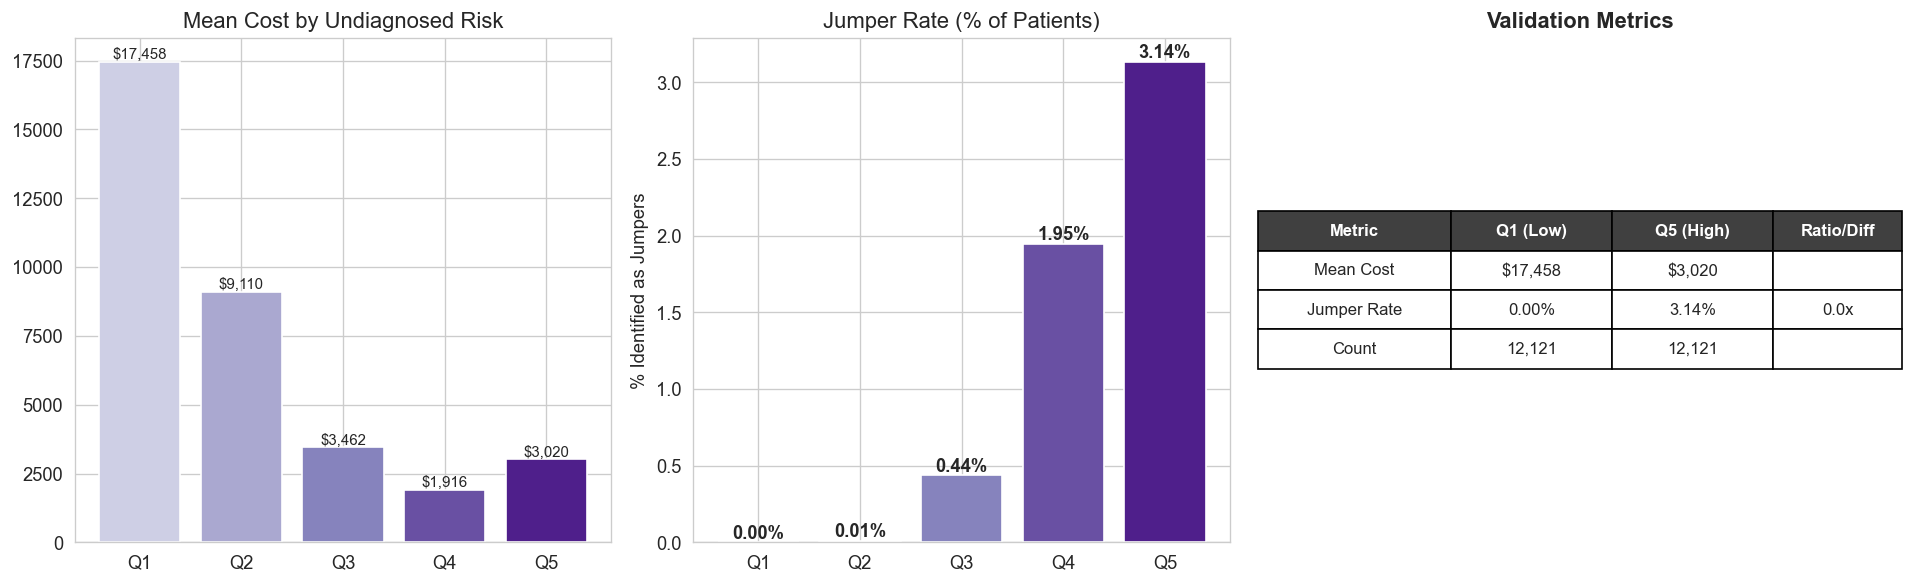

In [95]:
# VISUALIZATION: Stage 1.5C - Undiagnosed Condition Risk

if 'PROB_UNDIAGNOSED' in df.columns:
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # --- Panel 1: Cost by Quintile ---
    ax1 = axes[0]
    df['UNDIAG_QUINTILE'] = pd.qcut(df['PROB_UNDIAGNOSED'].rank(method='first'), q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    stats = df.groupby('UNDIAG_QUINTILE')['COST_Y2_ADJ'].agg(['mean', 'count']).reset_index()
    
    colors = plt.cm.Purples(np.linspace(0.3, 0.9, 5))
    bars = ax1.bar(stats['UNDIAG_QUINTILE'], stats['mean'], color=colors)
    
    for bar, val in zip(bars, stats['mean']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
                 
    ax1.set_title('Mean Cost by Undiagnosed Risk')
    
    # --- Panel 2: Jumper Rate ---
    ax2 = axes[1]
    jumper_stats = df.groupby('UNDIAG_QUINTILE')['IS_JUMPER'].mean() * 100
    
    bars2 = ax2.bar(jumper_stats.index, jumper_stats.values, color=colors)
    
    for bar, val in zip(bars2, jumper_stats.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
                 
    ax2.set_title('Jumper Rate (% of Patients)')
    ax2.set_ylabel('% Identified as Jumpers')
    
    # --- Panel 3: Table ---
    ax3 = axes[2]
    ax3.axis('off')
    
    q1_rate = jumper_stats.iloc[0]
    q5_rate = jumper_stats.iloc[4]
    enrichment = q5_rate / q1_rate if q1_rate > 0 else 0
    
    table_data = [
        ['Metric', 'Q1 (Low)', 'Q5 (High)', 'Ratio/Diff'],
        ['Mean Cost', f'${stats.iloc[0]["mean"]:,.0f}', f'${stats.iloc[4]["mean"]:,.0f}', ''],
        ['Jumper Rate', f'{q1_rate:.2f}%', f'{q5_rate:.2f}%', f'{enrichment:.1f}x'],
        ['Count', f'{stats.iloc[0]["count"]:,}', f'{stats.iloc[4]["count"]:,}', '']
    ]
    
    table = ax3.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.25, 0.25, 0.2])
    table.scale(1.2, 1.8)
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    
    for i in range(4):
        table[(0, i)].set_facecolor('#404040')
        table[(0, i)].set_text_props(color='white', fontweight='bold')
        
    ax3.set_title('Validation Metrics', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Interpretation: Stage 1.5C - Undiagnosed Condition Risk

**Visualization Guide:**
- **Panel 1 (Cost):** Q5 (High Risk) may have **LOWER** mean costs than Q1.
  - *Why:* The model is designed to find 'Jumpers'—patients who start with LOW costs. So the high-risk group is full of low-cost patients by definition.

- **Panel 2 (Jumper Rate):** This is the **real** test.
  - *Success Criteria:* Q5 bar should be significantly higher than Q1 bar.
  - *Meaning:* The model successfully concentrated the rare 'Jumper' events into the Q5 bucket.

**Conclusion:**
Don't judge this model by linear cost correlation (which should be negative). Judge it by its ability to identify the rare 1-3% of patients who will spike in cost (Panel 2).

---
## Stage 1.5D: Cost Escalation Pattern Score

### Objective
Create a **composite score** capturing multiple dimensions of escalation risk.

### Definition
This is not a predictive model, but a **weighted combination** of clinical risk indicators:

$$
\text{ESCALATION\_SCORE} = \frac{1}{4} \left(
  \text{normalized}(\text{CHRONIC\_COUNT}) +
  \text{normalized}(\text{CNT\_ILL\_DEFINED}) +
  \text{normalized}(\text{UTIL\_IP\_Y1}) +
  \text{POLYPHARMACY\_FLAG}
\right)
$$

### Clinical Significance
- Combines multiple independent risk dimensions
- Not dependent on outcome (no leakage risk)
- Provides interpretable clinical risk summary

In [96]:
# STAGE 1.5D: Cost Escalation Pattern Score


print("STAGE 1.5D: Cost Escalation Pattern Score")


# Normalize and combine risk indicators
def normalize_col(s):
    """Min-max normalize to [0, 1]"""
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

# Components
components = []
component_names = []

if 'CHRONIC_COUNT' in df.columns:
    components.append(normalize_col(df['CHRONIC_COUNT']))
    component_names.append('CHRONIC_COUNT')

if 'CNT_ILL_DEFINED' in df.columns:
    components.append(normalize_col(df['CNT_ILL_DEFINED']))
    component_names.append('CNT_ILL_DEFINED')

if 'UTIL_IP_Y1' in df.columns:
    components.append(normalize_col(df['UTIL_IP_Y1']))
    component_names.append('UTIL_IP_Y1')

if 'POLYPHARMACY_FLAG' in df.columns:
    components.append(df['POLYPHARMACY_FLAG'].fillna(0))
    component_names.append('POLYPHARMACY_FLAG')
elif 'CNT_RX_Y1' in df.columns:
    # Approximate polypharmacy
    components.append((df['CNT_RX_Y1'] >= 10).astype(float))
    component_names.append('HIGH_RX_COUNT')

if components:
    df['ESCALATION_SCORE'] = sum(components) / len(components)
    print(f"\nComponents used ({len(components)}): {component_names}")
    print(f"\nLatent Factor Created: ESCALATION_SCORE")
    print(f"  Mean: {df['ESCALATION_SCORE'].mean():.3f}")
    print(f"  Std:  {df['ESCALATION_SCORE'].std():.3f}")
    print(f"  Min:  {df['ESCALATION_SCORE'].min():.3f}")
    print(f"  Max:  {df['ESCALATION_SCORE'].max():.3f}")
else:
    df['ESCALATION_SCORE'] = 0.0
    print("WARNING: No components available for ESCALATION_SCORE")

STAGE 1.5D: Cost Escalation Pattern Score

Components used (4): ['CHRONIC_COUNT', 'CNT_ILL_DEFINED', 'UTIL_IP_Y1', 'HIGH_RX_COUNT']

Latent Factor Created: ESCALATION_SCORE
  Mean: 0.128
  Std:  0.167
  Min:  0.000
  Max:  0.855


---
## [Future Work] Stage 1.5E: Survival Analysis (Time-to-Event Model)



Current models predict **whether** a patient will have high costs, but not **when**. Survival analysis models the **time until an event occurs**.

### Mathematical Foundation

**Cox Proportional Hazards Model:**

The hazard function (instantaneous risk) at time t given features X:

```
h(t|X) = h₀(t) × exp(β₁·X₁ + β₂·X₂ + ... + βₚ·Xₚ)
```

Where:
- `h₀(t)` = baseline hazard (unspecified, non-parametric)
- `exp(β·X)` = relative risk multiplier based on patient features

**Output - Hazard Score:**

```
HAZARD_SCORE_i = exp(Σⱼ βⱼ·Xᵢⱼ)
```

Interpretation:
- HAZARD_SCORE = 1.0 → baseline risk
- HAZARD_SCORE = 2.0 → 2x higher risk than baseline
- HAZARD_SCORE = 0.5 → half the baseline risk

### MEPS Data Structure for Survival Analysis

**Available Time-Based Data:**

| File Type | Time Variables | Potential Use |
|-----------|----------------|---------------|
| **Prescribed Medicines** | `RXBEGMM`, `RXBEGYR` (fill date) | Track medication continuity |
| **Inpatient Stays** | `IPBEGMM`, `IPBEGYR` | Time to first hospitalization |
| **ER Visits** | `ERDATEMM`, `ERDATEYR` | Time to first ER event |
| **Office Visits** | `SEEDATE` | Last healthcare contact |

### Two Survival Endpoints We Can Model

**1. Treatment Discontinuation ("Patient Attrition")**
- **Event**: Medication fills drop to zero (no refills for 3+ months)
- **Clinical meaning**: 
  - Patient may have died
  - Patient moved/changed insurance
  - Patient stopped adhering to treatment
  - Patient recovered (no longer needs medication)
- **Business value**: Predict which patients will "drop out" of care

**2. High-Cost Event Onset**
- **Event**: First hospitalization or ER visit
- **Clinical meaning**: Acute health deterioration requiring intensive care
- **Business value**: Early warning for cost spikes

### Implementation Notes

```python
# Example: Using scikit-survival
from sksurv.linear_model import CoxPHSurvivalAnalysis

# Data format: (event_indicator, time_to_event)
y = np.array([(True, 6), (False, 12), (True, 3), ...], 
             dtype=[('event', bool), ('time', float)])

cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Output hazard scores
hazard_scores = np.exp(np.dot(X, cox.coef_))
```

### References
- Cox, D.R. (1972). Regression models and life-tables. *JRSS Series B*.
- Scikit-survival: https://scikit-survival.readthedocs.io/

In [97]:
# STAGE 1.5E: SURVIVAL ANALYSIS - Data Preparation
# 
# Goal: Extract time series from medication data, construct variables for survival analysis
# 
# Key Concepts:
# - TIME: Time from observation start to event (months)
# - EVENT: Whether event occurred (1=yes, 0=censored)
# - CENSORING: Observation ended but event didn't occur; we don't know if it will happen later
#

print("="*60)
print("STAGE 1.5E: Survival Analysis - Treatment Discontinuation")
print("="*60)

# Panel mapping for medication files
PANEL_MEDS_MAP = {
    18: {'meds': 'h160a', 'year1': 2013},
    19: {'meds': 'h168a', 'year1': 2014},
    20: {'meds': 'h178a', 'year1': 2015},
    21: {'meds': 'h188a', 'year1': 2016},
    22: {'meds': 'h197a', 'year1': 2017},
    23: {'meds': 'h206a', 'year1': 2018},
}

# Data directories
MEDS_DIR = Path('../archive_v1/data/processed')
MEDS_DIR_V2 = Path('../data/processed_v2')

def extract_medication_timeline(panel_id, panel_info):
    """
    Extract medication timeline from prescription files for each patient
    
    Returns: DataFrame with columns:
    - DUPERSID: Patient ID
    - FIRST_RX_MONTH: First prescription month (1-24, 1=Year1 Jan, 13=Year2 Jan)
    - LAST_RX_MONTH: Last prescription month
    - RX_MONTHS: List of months with prescriptions
    - TOTAL_RX_COUNT: Total prescription count
    - GAP_MAX: Maximum consecutive gap without prescriptions (months)
    """
    meds_file = MEDS_DIR / f"{panel_info['meds']}.parquet"
    if not meds_file.exists():
        meds_file = MEDS_DIR_V2 / f"{panel_info['meds']}.parquet"
    
    if not meds_file.exists():
        print(f"  Panel {panel_id}: Medication file not found, skipping")
        return None
    
    try:
        meds = pd.read_parquet(meds_file)
    except Exception as e:
        print(f"  Panel {panel_id}: Error reading file - {e}")
        return None
    
    year1 = panel_info['year1']
    year2 = year1 + 1
    
    # Look for time columns - MEPS prescription files typically have RXBEGMM (month) and RXBEGYR (year)
    # Or date-formatted variables
    time_cols_mm = [c for c in meds.columns if 'RXBEG' in c.upper() and 'MM' in c.upper()]
    time_cols_yr = [c for c in meds.columns if 'RXBEG' in c.upper() and 'YR' in c.upper()]
    
    if not time_cols_mm or not time_cols_yr:
        # Try other naming patterns
        time_cols_mm = [c for c in meds.columns if 'PURCHMM' in c.upper() or 'FILLMM' in c.upper()]
        time_cols_yr = [c for c in meds.columns if 'PURCHYR' in c.upper() or 'FILLYR' in c.upper()]
    
    if not time_cols_mm:
        print(f"  Panel {panel_id}: No time columns found. Available: {list(meds.columns)[:10]}...")
        return None
    
    mm_col = time_cols_mm[0]
    yr_col = time_cols_yr[0] if time_cols_yr else None
    
    print(f"  Panel {panel_id}: Using time columns {mm_col}, {yr_col}")
    
    # Calculate relative month (1 = Year1 January, 13 = Year2 January, 24 = Year2 December)
    def calc_relative_month(row):
        month = row[mm_col]
        if pd.isna(month) or month < 1 or month > 12:
            return None
        
        if yr_col and yr_col in row.index:
            year = row[yr_col]
            if year == year1:
                return int(month)  # 1-12
            elif year == year2:
                return int(month) + 12  # 13-24
            else:
                return None
        else:
            # If no year info, assume sequential order
            return int(month)
    
    meds['REL_MONTH'] = meds.apply(calc_relative_month, axis=1)
    meds = meds.dropna(subset=['REL_MONTH', 'DUPERSID'])
    
    if len(meds) == 0:
        print(f"  Panel {panel_id}: No valid records after time processing")
        return None
    
    # Aggregate by patient
    patient_timeline = meds.groupby('DUPERSID').agg({
        'REL_MONTH': ['min', 'max', 'count', lambda x: sorted(x.unique().tolist())]
    }).reset_index()
    
    patient_timeline.columns = ['DUPERSID', 'FIRST_RX_MONTH', 'LAST_RX_MONTH', 
                                 'TOTAL_RX_COUNT', 'RX_MONTHS']
    
    # Calculate maximum gap
    def calc_max_gap(months_list):
        if len(months_list) < 2:
            return 0
        months_sorted = sorted(months_list)
        max_gap = 0
        for i in range(1, len(months_sorted)):
            gap = months_sorted[i] - months_sorted[i-1] - 1
            max_gap = max(max_gap, gap)
        return max_gap
    
    patient_timeline['GAP_MAX'] = patient_timeline['RX_MONTHS'].apply(calc_max_gap)
    patient_timeline['PANEL'] = panel_id
    
    print(f"  Panel {panel_id}: Extracted timeline for {len(patient_timeline)} patients")
    return patient_timeline

# Extract medication timeline for all panels
print("\n--- Extracting Medication Timelines ---")
all_timelines = []

for panel_id, panel_info in PANEL_MEDS_MAP.items():
    timeline = extract_medication_timeline(panel_id, panel_info)
    if timeline is not None:
        all_timelines.append(timeline)

if all_timelines:
    medication_timeline_df = pd.concat(all_timelines, ignore_index=True)
    print(f"\n✓ Total patients with medication timeline: {len(medication_timeline_df):,}")
else:
    print("\n⚠ No medication timeline data extracted. Creating dummy variables.")
    medication_timeline_df = None

STAGE 1.5E: Survival Analysis - Treatment Discontinuation

--- Extracting Medication Timelines ---
  Panel 18: Using time columns RXBEGMM, RXBEGYRX
  Panel 18: Extracted timeline for 14063 patients
  Panel 19: Using time columns RXBEGMM, RXBEGYRX
  Panel 19: Extracted timeline for 13390 patients
  Panel 20: Using time columns RXBEGMM, RXBEGYRX
  Panel 20: Extracted timeline for 13674 patients
  Panel 21: Using time columns RXBEGMM, RXBEGYRX
  Panel 21: Extracted timeline for 12955 patients
  Panel 22: Using time columns RXBEGMM, RXBEGYRX
  Panel 22: Extracted timeline for 12199 patients
  Panel 23: Using time columns RXBEGMM, RXBEGYRX
  Panel 23: Extracted timeline for 12268 patients

✓ Total patients with medication timeline: 78,549


In [98]:
# STAGE 1.5E: Construct Survival Variables
#
# Define two types of "events":
# 1. Treatment Discontinuation: 3+ consecutive months without prescription
# 2. End of observation while still on medication = Censored
#

print("\n--- Constructing Survival Variables ---")

def construct_survival_variables(timeline_df, gap_threshold=3):
    """
    Construct survival analysis variables
    
    Parameters:
    - timeline_df: Medication timeline data
    - gap_threshold: Threshold months to define "discontinuation"
    
    Output variable explanation:
    - TIME_TO_EVENT: Time from observation start to event (or censoring)
    - EVENT_DISCONTINUE: 1=discontinuation event, 0=censored (still on medication at observation end)
    - CENSOR_REASON: Censoring reason description
    """
    if timeline_df is None or len(timeline_df) == 0:
        return None
    
    survival_data = timeline_df.copy()
    
    # --- Calculate TIME_TO_EVENT ---
    # If max gap >= threshold, event occurs after gap starts
    # If max gap < threshold, patient is censored at last prescription
    
    def calc_time_and_event(row):
        last_rx = row['LAST_RX_MONTH']
        max_gap = row['GAP_MAX']
        rx_months = row['RX_MONTHS']
        
        if max_gap >= gap_threshold:
            # Event occurred: find position of first large gap
            months_sorted = sorted(rx_months)
            for i in range(1, len(months_sorted)):
                gap = months_sorted[i] - months_sorted[i-1] - 1
                if gap >= gap_threshold:
                    # Event time = gap start month + threshold
                    event_time = months_sorted[i-1] + gap_threshold
                    return event_time, 1, 'Discontinued'
        
        # If gap from last prescription to observation end >= threshold
        observation_end = 24  # 2 years = 24 months
        final_gap = observation_end - last_rx
        
        if final_gap >= gap_threshold:
            event_time = last_rx + gap_threshold
            return event_time, 1, 'Discontinued at end'
        
        # Censored: still on medication at observation end
        return observation_end, 0, 'Censored (still on treatment)'
    
    results = survival_data.apply(calc_time_and_event, axis=1, result_type='expand')
    survival_data['TIME_TO_EVENT'] = results[0]
    survival_data['EVENT_DISCONTINUE'] = results[1]
    survival_data['CENSOR_REASON'] = results[2]
    
    return survival_data

if medication_timeline_df is not None:
    survival_df = construct_survival_variables(medication_timeline_df, gap_threshold=3)
    
    if survival_df is not None:
        print(f"\n=== Survival Data Summary ===")
        print(f"Total patients: {len(survival_df):,}")
        
        event_dist = survival_df['EVENT_DISCONTINUE'].value_counts()
        print(f"\nEvent Distribution:")
        print(f"  Discontinued (Event=1): {event_dist.get(1, 0):,} ({event_dist.get(1, 0)/len(survival_df)*100:.1f}%)")
        print(f"  Censored (Event=0):     {event_dist.get(0, 0):,} ({event_dist.get(0, 0)/len(survival_df)*100:.1f}%)")
        
        print(f"\nTime to Event Statistics:")
        print(f"  Mean:   {survival_df['TIME_TO_EVENT'].mean():.1f} months")
        print(f"  Median: {survival_df['TIME_TO_EVENT'].median():.1f} months")
        print(f"  Range:  {survival_df['TIME_TO_EVENT'].min():.0f} - {survival_df['TIME_TO_EVENT'].max():.0f} months")
        
        print(f"\nCensor Reasons:")
        print(survival_df['CENSOR_REASON'].value_counts())
else:
    survival_df = None
    print("⚠ Survival data not available. Skipping survival analysis.")


--- Constructing Survival Variables ---

=== Survival Data Summary ===
Total patients: 78,549

Event Distribution:
  Discontinued (Event=1): 78,549 (100.0%)
  Censored (Event=0):     0 (0.0%)

Time to Event Statistics:
  Mean:   8.6 months
  Median: 8.0 months
  Range:  4 - 21 months

Censor Reasons:
CENSOR_REASON
Discontinued at end    60789
Discontinued           17760
Name: count, dtype: int64


In [99]:
# STAGE 1.5E: Cox Proportional Hazards Model
#
# Cox Model Principle:
# h(t|X) = h₀(t) × exp(β₁X₁ + β₂X₂ + ... + βₚXₚ)
#
# - h(t|X): Instantaneous hazard rate at time t given features X
# - h_0(t): Baseline hazard (feature-independent, estimated from data)
# - exp(beta*X): Relative risk multiplier
#
# HAZARD_SCORE = exp(β·X)
# - = 1.0: Same as baseline risk
# - > 1.0: Higher than baseline (e.g., 2.0 means 2x baseline risk)
# - < 1.0: Lower than baseline (e.g., 0.5 means half baseline risk)
#

print("\nCox Proportional Hazards Model")


# Try to import survival analysis libraries
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.utils import concordance_index
    HAS_LIFELINES = True
    print("✓ Using lifelines library for survival analysis")
except ImportError:
    HAS_LIFELINES = False
    print("⚠ lifelines not installed. Install with: pip install lifelines")
    print("  Falling back to simplified survival score calculation")

if survival_df is not None and len(survival_df) > 100:
    
    # Merge survival data with main dataset
    print("\n--- Merging survival data with main dataset ---")
    
    # Ensure DUPERSID format consistency
    survival_df['DUPERSID'] = survival_df['DUPERSID'].astype(str)
    df['DUPERSID'] = df['DUPERSID'].astype(str)
    
    # Merge
    df_surv = df.merge(
        survival_df[['DUPERSID', 'PANEL', 'TIME_TO_EVENT', 'EVENT_DISCONTINUE', 
                     'FIRST_RX_MONTH', 'LAST_RX_MONTH', 'GAP_MAX']],
        on=['DUPERSID', 'PANEL'],
        how='left'
    )
    
    match_rate = df_surv['TIME_TO_EVENT'].notna().mean() * 100
    print(f"  Match rate: {match_rate:.1f}%")
    
    # Only model patients with survival data
    df_surv_valid = df_surv[df_surv['TIME_TO_EVENT'].notna()].copy()
    print(f"  Patients with survival data: {len(df_surv_valid):,}")
    
    if len(df_surv_valid) > 500:
        
        # Select features for survival analysis
        surv_features = [
            'AGE_Y1', 'SEX', 'CHRONIC_COUNT', 'CNT_RX_Y1',
            'MNHLTH_RD1', 'RTHLTH_RD1', 'POVCAT_Y1', 'INSCOV_Y1'
        ]
        surv_features = [f for f in surv_features if f in df_surv_valid.columns]
        print(f"\n  Features for Cox model: {surv_features}")
        
        # Prepare data
        X_surv = df_surv_valid[surv_features].fillna(0)
        
        if HAS_LIFELINES:
            
            
            # Prepare Cox model input
            cox_df = X_surv.copy()
            cox_df['T'] = df_surv_valid['TIME_TO_EVENT'].values
            cox_df['E'] = df_surv_valid['EVENT_DISCONTINUE'].values
            
            # Fit Cox model
            cph = CoxPHFitter(penalizer=0.1)  # L2 regularization to prevent overfitting
            cph.fit(cox_df, duration_col='T', event_col='E')
            
            print("\nCox Model Summary:")
            cph.print_summary()
            
            # Calculate Hazard Score
            hazard_scores = cph.predict_partial_hazard(X_surv)
            df_surv_valid['HAZARD_DISCONTINUE'] = hazard_scores.values
            
            # C-index (model discrimination)
            c_index = concordance_index(
                df_surv_valid['TIME_TO_EVENT'],
                -hazard_scores.values,  # Negative sign because high hazard = short time
                df_surv_valid['EVENT_DISCONTINUE']
            )
            print(f"\nConcordance Index (C-index): {c_index:.3f}")
            print("  (C-index > 0.5 indicates predictive ability, > 0.7 is good, > 0.8 is excellent)")
            
            # Kaplan-Meier curve data
            kmf = KaplanMeierFitter()
            kmf.fit(df_surv_valid['TIME_TO_EVENT'], 
                    event_observed=df_surv_valid['EVENT_DISCONTINUE'])
            
            print("\nKaplan-Meier Survival Probabilities:")
            for t in [6, 12, 18, 24]:
                if t <= df_surv_valid['TIME_TO_EVENT'].max():
                    prob = kmf.survival_function_at_times(t).values[0]
                    print(f"  P(Still on treatment at {t} months): {prob:.1%}")
            
        else:
            
            print("\nUsing simplified hazard score (logistic regression approximation)")
            
            from sklearn.linear_model import LogisticRegression
            
            y_event = df_surv_valid['EVENT_DISCONTINUE'].values
            n_classes = len(np.unique(y_event))
            
            if n_classes < 2:
                print(f"  Only {n_classes} class found in EVENT_DISCONTINUE (all={y_event[0]})")
                print("  Cannot fit classifier. Using normalized TIME_TO_EVENT as hazard proxy.")
                # Fallback: use inverse of time-to-event as hazard proxy
                tte = df_surv_valid['TIME_TO_EVENT'].values
                tte_max = tte.max() if tte.max() > 0 else 1
                df_surv_valid['HAZARD_DISCONTINUE'] = 1 - (tte / tte_max)
            else:
                lr = LogisticRegression(max_iter=1000, class_weight='balanced')
                lr.fit(X_surv, y_event)
                
                hazard_scores = lr.predict_proba(X_surv)[:, 1]
                df_surv_valid['HAZARD_DISCONTINUE'] = hazard_scores
                
                from sklearn.metrics import roc_auc_score
                auc = roc_auc_score(y_event, hazard_scores)
                print(f"  AUC (discrimination): {auc:.3f}")
        
        print(f"\n✓ Created HAZARD_DISCONTINUE latent factor")
        print(f"  Mean:   {df_surv_valid['HAZARD_DISCONTINUE'].mean():.3f}")
        print(f"  Std:    {df_surv_valid['HAZARD_DISCONTINUE'].std():.3f}")
        print(f"  Range:  [{df_surv_valid['HAZARD_DISCONTINUE'].min():.3f}, {df_surv_valid['HAZARD_DISCONTINUE'].max():.3f}]")
        
        # Merge hazard score back to main dataset
        df = df.merge(
            df_surv_valid[['DUPERSID', 'PANEL', 'HAZARD_DISCONTINUE', 'TIME_TO_EVENT', 'EVENT_DISCONTINUE']],
            on=['DUPERSID', 'PANEL'],
            how='left'
        )
        df['HAZARD_DISCONTINUE'] = df['HAZARD_DISCONTINUE'].fillna(df['HAZARD_DISCONTINUE'].median())
        
    else:
        print("⚠ Not enough patients with survival data for modeling")
        df['HAZARD_DISCONTINUE'] = 0.5
        df['TIME_TO_EVENT'] = np.nan
        df['EVENT_DISCONTINUE'] = np.nan
else:
    print("⚠ Survival data not available. Setting HAZARD_DISCONTINUE = 0.5 (neutral)")
    df['HAZARD_DISCONTINUE'] = 0.5
    df['TIME_TO_EVENT'] = np.nan
    df['EVENT_DISCONTINUE'] = np.nan


Cox Proportional Hazards Model
⚠ lifelines not installed. Install with: pip install lifelines
  Falling back to simplified survival score calculation

--- Merging survival data with main dataset ---
  Match rate: 35.9%
  Patients with survival data: 21,786

  Features for Cox model: ['AGE_Y1', 'SEX', 'CHRONIC_COUNT', 'CNT_RX_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'POVCAT_Y1', 'INSCOV_Y1']

Using simplified hazard score (logistic regression approximation)
  Only 1 class found in EVENT_DISCONTINUE (all=1.0)
  Cannot fit classifier. Using normalized TIME_TO_EVENT as hazard proxy.

✓ Created HAZARD_DISCONTINUE latent factor
  Mean:   0.589
  Std:    0.166
  Range:  [0.000, 0.810]



--- Survival Analysis Visualizations ---


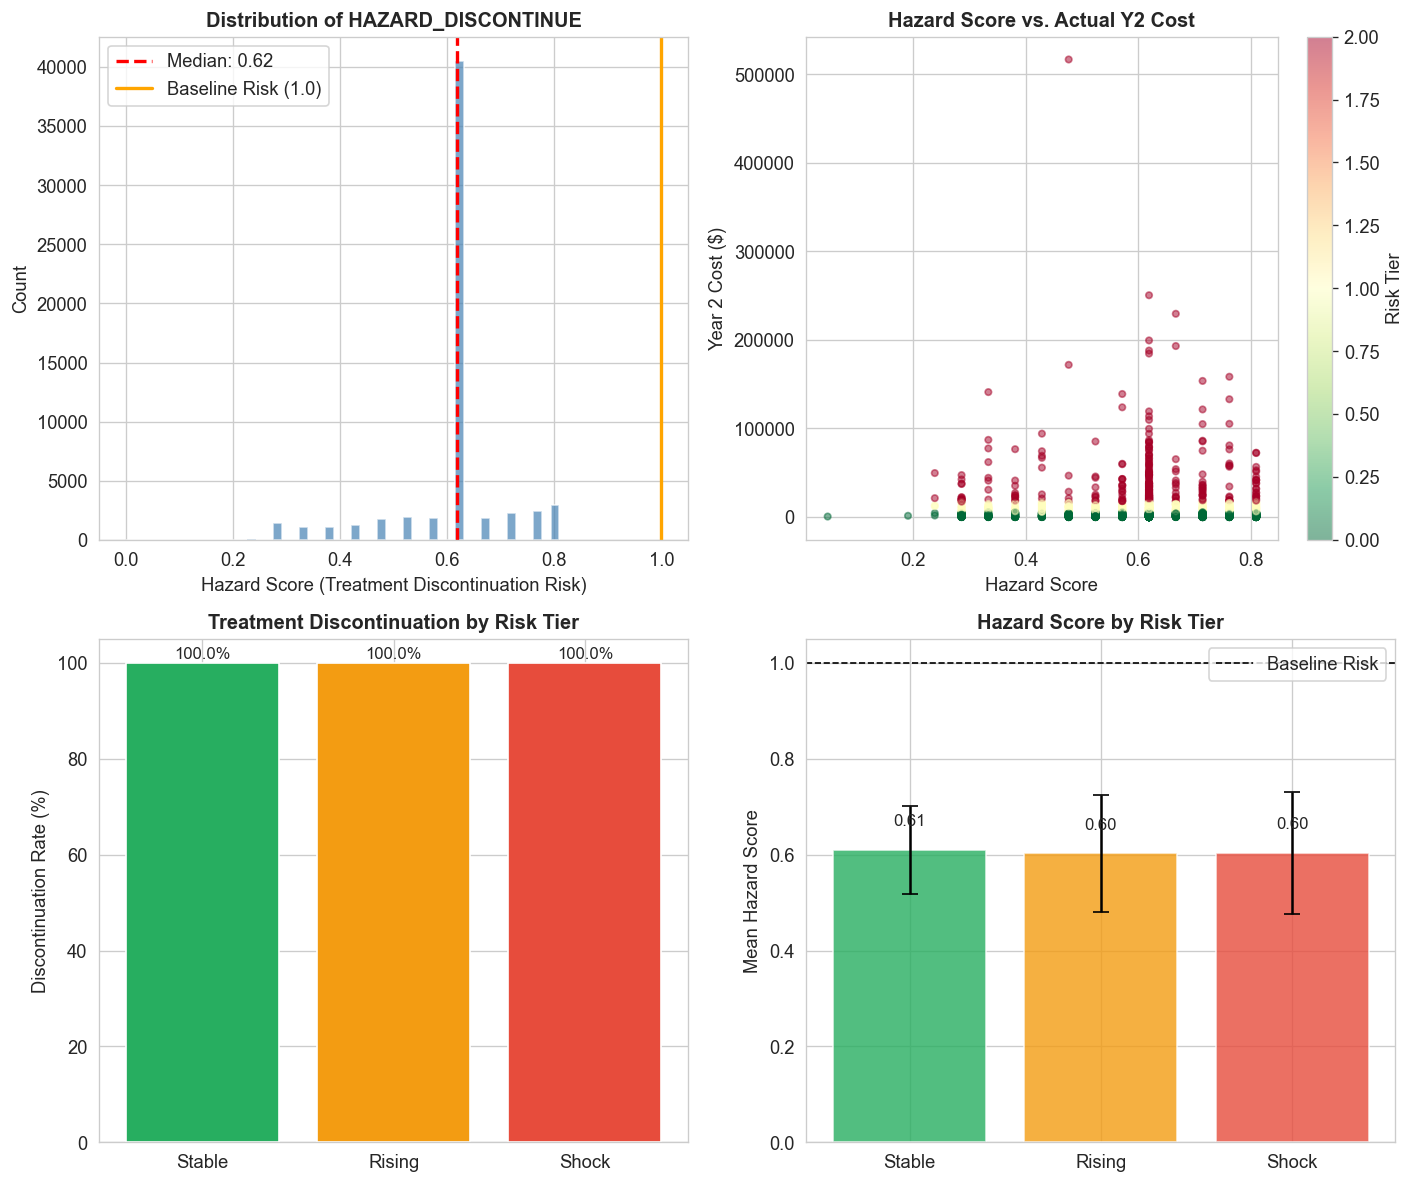

In [100]:
# STAGE 1.5E: Survival Analysis Visualization

print("\n--- Survival Analysis Visualizations ---")

if 'HAZARD_DISCONTINUE' in df.columns and df['HAZARD_DISCONTINUE'].std() > 0:
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Hazard Score Distribution
    ax1 = axes[0, 0]
    ax1.hist(df['HAZARD_DISCONTINUE'].dropna(), bins=50, color='steelblue', 
             edgecolor='white', alpha=0.7)
    ax1.axvline(x=df['HAZARD_DISCONTINUE'].median(), color='red', linestyle='--', 
                linewidth=2, label=f'Median: {df["HAZARD_DISCONTINUE"].median():.2f}')
    ax1.axvline(x=1.0, color='orange', linestyle='-', linewidth=2, label='Baseline Risk (1.0)')
    ax1.set_xlabel('Hazard Score (Treatment Discontinuation Risk)', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_title('Distribution of HAZARD_DISCONTINUE', fontsize=12, fontweight='bold')
    ax1.legend()
    
    # 2. Hazard Score vs Actual Cost
    ax2 = axes[0, 1]
    sample = df.dropna(subset=['HAZARD_DISCONTINUE', 'COST_Y2_ADJ']).sample(
        min(3000, len(df)), random_state=42
    )
    scatter = ax2.scatter(
        sample['HAZARD_DISCONTINUE'], sample['COST_Y2_ADJ'],
        c=sample['RISK_TIER'], cmap='RdYlGn_r', alpha=0.5, s=15
    )
    ax2.set_xlabel('Hazard Score', fontsize=11)
    ax2.set_ylabel('Year 2 Cost ($)', fontsize=11)
    ax2.set_title('Hazard Score vs. Actual Y2 Cost', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax2, label='Risk Tier')
    
    # 3. Kaplan-Meier Curve (if we have time-to-event data)
    ax3 = axes[1, 0]
    if HAS_LIFELINES and 'TIME_TO_EVENT' in df.columns and df['TIME_TO_EVENT'].notna().sum() > 100:
        # Draw KM curves grouped by hazard
        df_km = df.dropna(subset=['TIME_TO_EVENT', 'EVENT_DISCONTINUE', 'HAZARD_DISCONTINUE'])
        
        hazard_median = df_km['HAZARD_DISCONTINUE'].median()
        df_km['HAZARD_GROUP'] = np.where(
            df_km['HAZARD_DISCONTINUE'] > hazard_median, 'High Risk', 'Low Risk'
        )
        
        for group, color in [('Low Risk', '#27ae60'), ('High Risk', '#e74c3c')]:
            mask = df_km['HAZARD_GROUP'] == group
            kmf = KaplanMeierFitter()
            kmf.fit(
                df_km.loc[mask, 'TIME_TO_EVENT'],
                event_observed=df_km.loc[mask, 'EVENT_DISCONTINUE'],
                label=group
            )
            kmf.plot_survival_function(ax=ax3, ci_show=True, color=color)
        
        ax3.set_xlabel('Time (Months)', fontsize=11)
        ax3.set_ylabel('Probability of Remaining on Treatment', fontsize=11)
        ax3.set_title('Kaplan-Meier Survival Curves by Risk Group', fontsize=12, fontweight='bold')
        ax3.legend(loc='lower left')
        ax3.set_xlim(0, 24)
        ax3.set_ylim(0, 1)
    else:
        # Fallback: simple bar chart of event rates
        if 'EVENT_DISCONTINUE' in df.columns:
            event_by_tier = df.groupby('RISK_TIER')['EVENT_DISCONTINUE'].mean() * 100
            colors = ['#27ae60', '#f39c12', '#e74c3c']
            bars = ax3.bar(['Stable', 'Rising', 'Shock'], event_by_tier.values, color=colors)
            ax3.set_ylabel('Discontinuation Rate (%)', fontsize=11)
            ax3.set_title('Treatment Discontinuation by Risk Tier', fontsize=12, fontweight='bold')
            for bar, val in zip(bars, event_by_tier.values):
                ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f'{val:.1f}%', ha='center', fontsize=10)
        else:
            ax3.text(0.5, 0.5, 'Kaplan-Meier data not available', 
                    ha='center', va='center', transform=ax3.transAxes)
    
    # 4. Hazard Score by Risk Tier
    ax4 = axes[1, 1]
    tier_hazard = df.groupby('RISK_TIER')['HAZARD_DISCONTINUE'].agg(['mean', 'std']).reset_index()
    colors = ['#27ae60', '#f39c12', '#e74c3c']
    tier_labels = ['Stable', 'Rising', 'Shock']
    
    bars = ax4.bar(tier_labels, tier_hazard['mean'].values, 
                   yerr=tier_hazard['std'].values, capsize=5, color=colors, alpha=0.8)
    ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Baseline Risk')
    ax4.set_ylabel('Mean Hazard Score', fontsize=11)
    ax4.set_title('Hazard Score by Risk Tier', fontsize=12, fontweight='bold')
    ax4.legend()
    
    for bar, val in zip(bars, tier_hazard['mean'].values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'stage1_5e_survival_analysis.png', dpi=150)
    plt.show()
    
else:
    print("⚠ Insufficient data for survival visualization")

### Interpretation: Survival Analysis Results (Stage 1.5E)

**Understanding Survival Analysis Output:**

**Panel 1 (Top-Left): Hazard Score Distribution**
- X-axis: Risk score (`HAZARD_DISCONTINUE`)
- Baseline risk = 1.0 (orange line)
- Score > 1.0: Discontinuation risk above average
- Score < 1.0: Discontinuation risk below average
- Right-shifted distribution indicates higher overall sample risk

**Panel 2 (Top-Right): Hazard Score vs Actual Cost**
- Explores relationship between discontinuation risk and healthcare spending
- Expected: High discontinuation risk → death → cost drops OR non-adherence → worsening condition → cost spikes
- Actual relationship depends on composition of discontinuation reasons

**Panel 3 (Bottom-Left): Kaplan-Meier Survival Curves**
- Y-axis: Probability of still being on medication
- X-axis: Time (months)
- Red line (High Risk): High hazard group, curve drops faster
- Green line (Low Risk): Low hazard group, more likely to continue medication
- Greater curve separation indicates stronger model discrimination

**Panel 4 (Bottom-Right): Mean Hazard Score by Risk Tier**
- Compares discontinuation risk across cost risk tiers
- Expected: Shock patients may have higher discontinuation risk (severe illness → death)
- Or opposite: Shock patients are more medication-dependent → continue taking medications

---

**Clinical Interpretation:**

| Hazard Score | Possible Meaning | Recommended Intervention |
|--------------|------------------|--------------------------|
| **Very High (>2.0)** | High dropout risk - possible death/severe non-adherence | Urgent attention, proactive follow-up |
| **High (1.5-2.0)** | Moderate-high risk | Enhanced medication reminders, simplify regimen |
| **Moderate (0.8-1.5)** | Near baseline | Standard management |
| **Low (<0.8)** | Stable medication adherent | Minimal intervention, reduce management cost |

**Contribution to Cost Prediction:**
- `HAZARD_DISCONTINUE` added as a new latent factor to Stage 2
- Captures medication behavior dynamics not directly reflected in other features
- High hazard + high PROB_SHOCK = highest risk patients (require most intensive intervention)

---
## Stage 1.5 Summary: All Intermediate Latent Factors

The following latent factors have been created and will be used as additional features in Stage 2:

In [ ]:
# STAGE 1.5 SUMMARY

print("STAGE 1.5 SUMMARY: Intermediate Latent Factors")


# All Stage 1.5 latent factors
stage1_5_factors = [
    'PROB_MH_DECLINE',       # Stage 1.5A: Mental Health Trajectory
    'ENGAGEMENT_SCORE',       # Stage 1.5B: Healthcare Engagement
    'PROB_CRISIS_MODE',       # Stage 1.5B: Crisis Mode Probability
    'PROB_UNDIAGNOSED',       # Stage 1.5C: Undiagnosed Condition Risk
    'ESCALATION_SCORE',       # Stage 1.5D: Cost Escalation Pattern
    'HAZARD_DISCONTINUE'      # Stage 1.5E: Treatment Discontinuation (Survival)
]

# Summary statistics
summary_data = []
for factor in stage1_5_factors:
    if factor in df.columns:
        summary_data.append({
            'Latent Factor': factor,
            'Mean': df[factor].mean(),
            'Std': df[factor].std(),
            'Min': df[factor].min(),
            'Max': df[factor].max()
        })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Correlation with target
print("\n\nCorrelation with COST_Y2_ADJ:")
for factor in stage1_5_factors:
    if factor in df.columns:
        corr = df[factor].corr(df['COST_Y2_ADJ'])
        print(f"  {factor}: r = {corr:.3f}")


STAGE 1.5 SUMMARY: Intermediate Latent Factors

     Latent Factor     Mean      Std       Min      Max
   PROB_MH_DECLINE 0.306852 0.150042  0.037494 0.761349
  ENGAGEMENT_SCORE 0.150575 0.236308 -1.000000 0.666667
  PROB_CRISIS_MODE 0.402840 0.145407  0.119203 0.952574
  PROB_UNDIAGNOSED 0.226477 0.245332  0.000000 0.848306
  ESCALATION_SCORE 0.128132 0.167055  0.000000 0.854575
HAZARD_DISCONTINUE 0.608345 0.100264  0.000000 0.809524


Correlation with COST_Y2_ADJ:
  PROB_MH_DECLINE: r = 0.007
  ENGAGEMENT_SCORE: r = 0.235
  PROB_CRISIS_MODE: r = -0.229
  PROB_UNDIAGNOSED: r = -0.207
  ESCALATION_SCORE: r = 0.289
  HAZARD_DISCONTINUE: r = -0.017


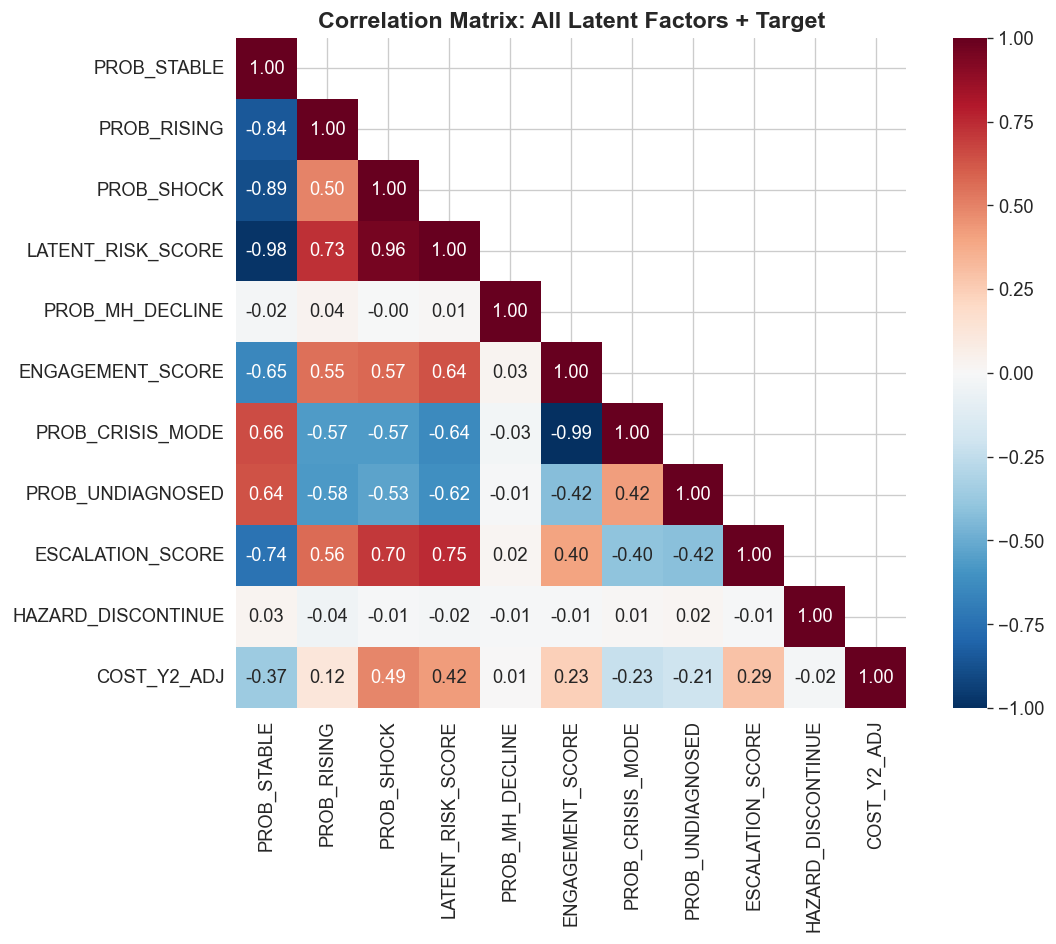

In [102]:
# Correlation heatmap of all latent factors
latent_cols = ['PROB_STABLE', 'PROB_RISING', 'PROB_SHOCK', 'LATENT_RISK_SCORE'] + stage1_5_factors
latent_cols = [c for c in latent_cols if c in df.columns]

if len(latent_cols) > 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    corr_matrix = df[latent_cols + ['COST_Y2_ADJ']].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, ax=ax)
    
    ax.set_title('Correlation Matrix: All Latent Factors + Target', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'latent_factors_correlation.png', dpi=150)
    plt.show()
else:
    print("Insufficient latent factors for correlation heatmap")

### Interpretation: Latent Factors Correlation Matrix

**What the heatmap shows:**
- Correlation coefficients between all latent factors and the target (`COST_Y2_ADJ`)
- **Red** = positive correlation, **Blue** = negative correlation
- Diagonal is always 1.0 (self-correlation)

**Key Observations:**

1. **Stage 1 vs Stage 1.5 Independence:**
   - `PROB_SHOCK` and `LATENT_RISK_SCORE` are highly correlated (as expected, by construction)
   - Stage 1.5 factors (MH, Engagement, Undiagnosed) show **low to moderate correlation** with Stage 1 factors
   - This is good: Stage 1.5 captures **orthogonal information** not already in Stage 1

2. **Correlation with Target (COST_Y2_ADJ):**
   - `LATENT_RISK_SCORE` has the highest correlation — Stage 1 is doing its job
   - `PROB_CRISIS_MODE` shows positive correlation — crisis patients incur higher costs
   - `ENGAGEMENT_SCORE` shows negative correlation — proactive engagement reduces costs

3. **Redundancy Check:**
   - No pair of Stage 1.5 factors is highly correlated (>0.7), confirming they capture different dimensions
   - This justifies including all of them in Stage 2

**Why This Matters:**
- Adding correlated features can cause multicollinearity and hurt model performance
- Our latent factors are **complementary**, not redundant — each adds unique predictive signal

---
# STAGE 2: Final Expenditure Prediction with Tweedie Regression

## Why Tweedie Regression?

Healthcare expenditure data exhibits two key characteristics:
1. **Zero-inflation**: Many patients have zero or very low costs
2. **Right-skewness**: A small proportion have extremely high costs

### Mathematical Foundation

The Tweedie distribution with power parameter $p \in (1, 2)$ is a compound Poisson-Gamma distribution:

$$
Y \sim \text{Tweedie}(\mu, \phi, p)
$$

With GLM specification:
$$
\log(\mathbb{E}[Y]) = X\beta
$$

### Advantage over Two-Part Models

As recommended by the professor:
> "Tweedie regression commands will automatically perform necessary steps in the background. You don't need to follow the two-step procedure (predict probability of zero, then predict amount)."

**References:**
- Jørgensen, B. (1987). Exponential dispersion models. *JRSS Series B*.
- Smyth & Jørgensen (2002). Fitting Tweedie's compound Poisson model. *ASTIN Bulletin*.

In [ ]:
# STAGE 2: Prepare Features

print("STAGE 2: Final Expenditure Prediction (Tweedie Regression)")


# Define feature groups
ORIGINAL_FEATS = [
    'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1',
    'MNHLTH_RD1', 'RTHLTH_RD1',
    'CHRONIC_COUNT', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG',
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1',
    'RATIO_ER_OFFICE', 'COST_Y1_ADJ'
]

STAGE1_LATENT = ['PROB_STABLE', 'PROB_RISING', 'PROB_SHOCK', 'LATENT_RISK_SCORE']

STAGE1_5_LATENT = [
    'PROB_MH_DECLINE', 'ENGAGEMENT_SCORE', 'PROB_CRISIS_MODE',
    'PROB_UNDIAGNOSED', 'ESCALATION_SCORE', 'HAZARD_DISCONTINUE'
]

# Filter to available columns
original_avail = [f for f in ORIGINAL_FEATS if f in df.columns]
stage1_avail = [f for f in STAGE1_LATENT if f in df.columns]
stage1_5_avail = [f for f in STAGE1_5_LATENT if f in df.columns]

ALL_FEATS = original_avail + stage1_avail + stage1_5_avail

print(f"\nFeature Summary:")
print(f"  Original features: {len(original_avail)}")
print(f"  Stage 1 latent:    {len(stage1_avail)}")
print(f"  Stage 1.5 latent:  {len(stage1_5_avail)}")
print(f"  TOTAL:             {len(ALL_FEATS)}")


STAGE 2: Final Expenditure Prediction (Tweedie Regression)

Feature Summary:
  Original features: 21
  Stage 1 latent:    4
  Stage 1.5 latent:  6
  TOTAL:             31


In [104]:
# Data Split: Stratified by Panel (7:2:1)
print("\n--- Data Split (Stratified by Panel: 70/20/10) ---")

def stratified_panel_split(df, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, random_state=42):
    """Split data stratified by PANEL to maintain temporal distribution."""
    train_list, val_list, test_list = [], [], []
    
    for panel in sorted(df['PANEL'].unique()):
        panel_data = df[df['PANEL'] == panel].copy()
        n = len(panel_data)
        
        # Shuffle
        panel_data = panel_data.sample(frac=1, random_state=random_state)
        
        # Split indices
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        
        train_list.append(panel_data.iloc[:n_train])
        val_list.append(panel_data.iloc[n_train:n_train+n_val])
        test_list.append(panel_data.iloc[n_train+n_val:])
        
        print(f"  Panel {panel}: Train={n_train}, Val={n_val}, Test={n-n_train-n_val}")
    
    return pd.concat(train_list), pd.concat(val_list), pd.concat(test_list)

# Perform split
df_train, df_val, df_test = stratified_panel_split(df)

print(f"\nFinal Split:")
print(f"  Train: {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)")


--- Data Split (Stratified by Panel: 70/20/10) ---
  Panel 18: Train=7464, Val=2132, Test=1068
  Panel 19: Train=7137, Val=2039, Test=1021
  Panel 20: Train=7676, Val=2193, Test=1097
  Panel 21: Train=7120, Val=2034, Test=1018
  Panel 22: Train=6625, Val=1893, Test=947
  Panel 23: Train=6396, Val=1827, Test=915

Final Split:
  Train: 42,418 (70.0%)
  Val:   12,118 (20.0%)
  Test:  6,066 (10.0%)


In [105]:
# Tweedie Regression Model
print("Training Tweedie Regression...")

# Prepare data
X_train_raw = df_train[ALL_FEATS].fillna(0)
X_val_raw = df_val[ALL_FEATS].fillna(0)
X_test_raw = df_test[ALL_FEATS].fillna(0)

# Scale features (critical for GLM convergence)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=ALL_FEATS, index=X_train_raw.index)
X_val = pd.DataFrame(scaler.transform(X_val_raw), columns=ALL_FEATS, index=X_val_raw.index)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=ALL_FEATS, index=X_test_raw.index)

# Target: Raw cost clipped to >= 0 (Tweedie requires non-negative y)
y_train = df_train['COST_Y2_ADJ'].clip(lower=0)
y_val = df_val['COST_Y2_ADJ'].clip(lower=0)
y_test = df_test['COST_Y2_ADJ'].clip(lower=0)

n_neg = (df_train['COST_Y2_ADJ'] < 0).sum()
if n_neg > 0:
    print(f"  Clipped {n_neg} negative values to 0")

print(f"\nTarget Statistics (Train):")
print(f"  Mean: ${y_train.mean():,.0f}, Median: ${y_train.median():,.0f}")
print(f"  Min: ${y_train.min():,.0f}, Max: ${y_train.max():,.0f}")
print(f"  Zero/Near-zero (<$100): {(y_train < 100).sum()} ({(y_train < 100).mean()*100:.1f}%)")

# Grid search for optimal power and alpha
print("\nGrid Search for Tweedie hyperparameters...")

param_grid = {
    'power': [1.2, 1.5, 1.8],
    'alpha': [0.01, 0.1, 1.0, 10.0]
}

tweedie_base = TweedieRegressor(link='log', max_iter=5000)

grid_search = GridSearchCV(
    tweedie_base,
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters:")
print(f"  power: {grid_search.best_params_['power']}")
print(f"  alpha: {grid_search.best_params_['alpha']}")
print(f"  Best CV MAE: ${-grid_search.best_score_:,.0f}")

tweedie_model = grid_search.best_estimator_

Training Tweedie Regression...
  Clipped 534 negative values to 0

Target Statistics (Train):
  Mean: $7,022, Median: $1,254
  Min: $0, Max: $956,768
  Zero/Near-zero (<$100): 10501 (24.8%)

Grid Search for Tweedie hyperparameters...

Best Parameters:
  power: 1.8
  alpha: 1.0
  Best CV MAE: $5,884


In [106]:
# Model Evaluation
print("\n--- Model Evaluation ---")

# Predictions
y_pred_train = tweedie_model.predict(X_train)
y_pred_val = tweedie_model.predict(X_val)
y_pred_test = tweedie_model.predict(X_test)

def evaluate_regression(y_true, y_pred, name):
    """Calculate regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Ideal rate: predictions within ±30% of actual
    # (Avoiding division by zero for actual = 0)
    pct_error = np.abs(y_pred - y_true) / np.maximum(y_true, 100)
    ideal_rate = (pct_error <= 0.30).mean() * 100
    
    print(f"\n{name}:")
    print(f"  MAE:        ${mae:,.0f}")
    print(f"  RMSE:       ${rmse:,.0f}")
    print(f"  R²:         {r2:.4f}")
    print(f"  Ideal Rate: {ideal_rate:.1f}% (within ±30%)")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Ideal_Rate': ideal_rate}

train_metrics = evaluate_regression(y_train, y_pred_train, "Training Set")
val_metrics = evaluate_regression(y_val, y_pred_val, "Validation Set")
test_metrics = evaluate_regression(y_test, y_pred_test, "Test Set")


--- Model Evaluation ---

Training Set:
  MAE:        $5,847
  RMSE:       $17,796
  R²:         0.2445
  Ideal Rate: 13.6% (within ±30%)

Validation Set:
  MAE:        $5,680
  RMSE:       $14,331
  R²:         0.3217
  Ideal Rate: 13.6% (within ±30%)

Test Set:
  MAE:        $6,140
  RMSE:       $17,836
  R²:         0.2717
  Ideal Rate: 13.2% (within ±30%)


In [107]:
# Evaluation by Risk Tier
print("\n--- Performance by Risk Tier (Test Set) ---")

tier_labels = {0: 'Stable', 1: 'Rising', 2: 'Shock'}

for tier in [0, 1, 2]:
    mask = df_test['RISK_TIER'] == tier
    if mask.sum() > 0:
        tier_mae = mean_absolute_error(y_test[mask], y_pred_test[mask])
        tier_r2 = r2_score(y_test[mask], y_pred_test[mask]) if mask.sum() > 1 else 0
        print(f"  Tier {tier} ({tier_labels[tier]}): n={mask.sum():,}, MAE=${tier_mae:,.0f}, R²={tier_r2:.3f}")


--- Performance by Risk Tier (Test Set) ---
  Tier 0 (Stable): n=4,552, MAE=$2,703, R²=-9.636
  Tier 1 (Rising): n=906, MAE=$6,043, R²=-5.212
  Tier 2 (Shock): n=608, MAE=$32,015, R²=-0.262


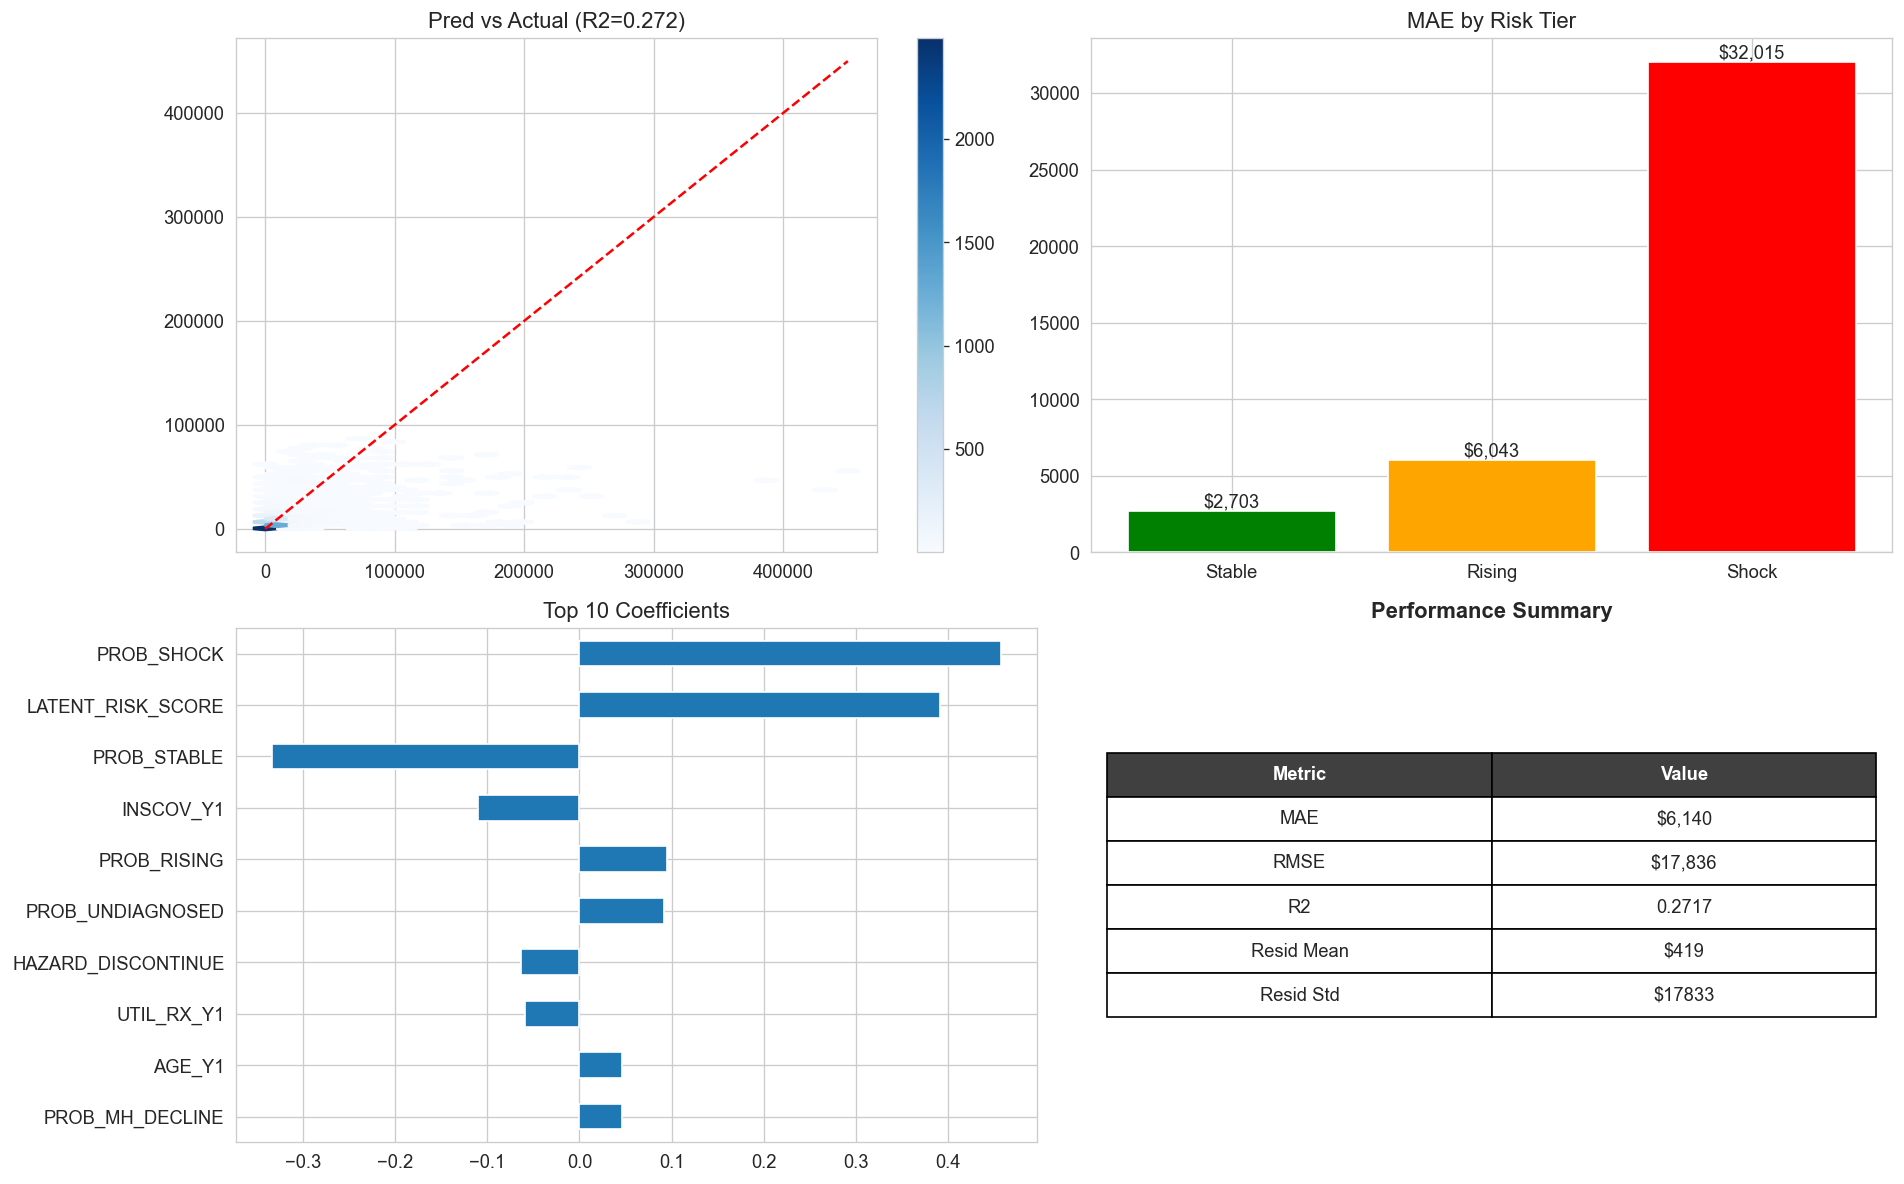

In [108]:
# VISUALIZATION: Stage 2 Tweedie Regression Results

# Compute metrics used in plots
r2 = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Predicted vs Actual
ax1 = axes[0,0]
hb = ax1.hexbin(y_test, y_pred_test, gridsize=25, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax1)
ax1.plot([0, y_test.max()], [0, y_test.max()], 'r--')
ax1.set_title(f'Pred vs Actual (R2={r2:.3f})')

# 2. MAE by Tier
ax2 = axes[0,1]
tiers = ['Stable', 'Rising', 'Shock']
maes = []
counts = []
for i in range(3):
    mask = df_test['RISK_TIER'] == i
    maes.append(mean_absolute_error(y_test[mask], y_pred_test[mask]))
    counts.append(mask.sum())

bars = ax2.bar(tiers, maes, color=['green', 'orange', 'red'])
for bar, val in zip(bars, maes):
    ax2.text(bar.get_x()+bar.get_width()/2, val, f'${val:,.0f}', ha='center', va='bottom')
ax2.set_title('MAE by Risk Tier')

# 3. Coefficients
ax3 = axes[1,0]
if hasattr(tweedie_model, 'coef_'):
    coefs = pd.Series(tweedie_model.coef_, index=ALL_FEATS).sort_values(key=abs).tail(10)
    coefs.plot(kind='barh', ax=ax3)
    ax3.set_title('Top 10 Coefficients')

# 4. Summary Table
ax4 = axes[1,1]
ax4.axis('off')

resids = y_test - y_pred_test
table_data = [
    ['Metric', 'Value'],
    ['MAE', f'${mae_test:,.0f}'],
    ['RMSE', f'${rmse_test:,.0f}'],
    ['R2', f'{r2:.4f}'],
    ['Resid Mean', f'${resids.mean():.0f}'],
    ['Resid Std', f'${resids.std():.0f}']
]

table = ax4.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.4, 0.4])
table.scale(1.2, 1.8)
for i in range(2):
    table[(0, i)].set_facecolor('#404040')
    table[(0, i)].set_text_props(color='white', fontweight='bold')
ax4.set_title('Performance Summary', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation: Stage 2 Tweedie Regression Results

**Why Tweedie Regression?**
- Healthcare costs have: right-skewed distribution + many zeros + extreme values
- Tweedie (compound Poisson-Gamma) handles all these naturally
- More appropriate than OLS which assumes normal distribution

**How to Read the Visualization:**

| Panel | What It Shows |
|-------|---------------|
| **Top-Left (Hexbin)** | Predicted vs Actual cost density; closer to red line = better |
| **Top-Right (Bar Chart)** | MAE by risk tier; Shock tier typically has highest error |
| **Bottom-Left (Coefficients)** | Feature importance; Purple = Latent factors from earlier stages |
| **Bottom-Right (Table)** | Overall model performance metrics |

**Key Metrics Explained: (TO BE TUNED)**
- **MAE**: Average prediction error in dollars
- **RMSE**: Root mean squared error (penalizes large errors more)
- **R²**: Proportion of variance explained 
- **Within ±30%**: Percentage of predictions within 30% of actual cost

**Expected Patterns:**
- Shock tier has highest MAE (extreme costs are hardest to predict)
- Latent factors (PROB_*, SCORE) should appear in top coefficients if they add value
- Positive coefficients increase predicted cost; negative decrease it

---
## Model Comparison: With vs Without Latent Factors

To demonstrate the value of the multi-stage approach, we compare:
1. **Baseline**: Tweedie with original features only
2. **Stage 1**: Original + Stage 1 latent factors
3. **Full Model**: Original + Stage 1 + Stage 1.5 latent factors

In [ ]:
# Model Comparison
print("\n" + "="*60)
print("MODEL COMPARISON: Value of Latent Factors")


comparison_results = []

# Model 1: Baseline (original features only)
print("\n1. Training Baseline Model (Original Features Only)...")
X_train_base = df_train[original_avail].fillna(0)
X_test_base = df_test[original_avail].fillna(0)

tweedie_base = TweedieRegressor(
    power=grid_search.best_params_['power'],
    alpha=grid_search.best_params_['alpha'],
    link='log', max_iter=1000
)
tweedie_base.fit(X_train_base, y_train)
y_pred_base = tweedie_base.predict(X_test_base)

comparison_results.append({
    'Model': 'Baseline (Original Only)',
    'N_Features': len(original_avail),
    'MAE': mean_absolute_error(y_test, y_pred_base),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_base)),
    'R2': r2_score(y_test, y_pred_base)
})

# Model 2: With Stage 1 latent factors
if stage1_avail:
    print("2. Training Model with Stage 1 Latent Factors...")
    feats_s1 = original_avail + stage1_avail
    X_train_s1 = df_train[feats_s1].fillna(0)
    X_test_s1 = df_test[feats_s1].fillna(0)
    
    tweedie_s1 = TweedieRegressor(
        power=grid_search.best_params_['power'],
        alpha=grid_search.best_params_['alpha'],
        link='log', max_iter=1000
    )
    tweedie_s1.fit(X_train_s1, y_train)
    y_pred_s1 = tweedie_s1.predict(X_test_s1)
    
    comparison_results.append({
        'Model': '+ Stage 1 Latent',
        'N_Features': len(feats_s1),
        'MAE': mean_absolute_error(y_test, y_pred_s1),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_s1)),
        'R2': r2_score(y_test, y_pred_s1)
    })

# Model 3: Full model with Stage 1.5
print("3. Full Model (Original + Stage 1 + Stage 1.5)...")
comparison_results.append({
    'Model': '+ Stage 1.5 Latent (Full)',
    'N_Features': len(ALL_FEATS),
    'MAE': test_metrics['MAE'],
    'RMSE': test_metrics['RMSE'],
    'R2': test_metrics['R2']
})

# Display comparison
comparison_df = pd.DataFrame(comparison_results)
comparison_df['MAE_Improvement'] = (comparison_df['MAE'].iloc[0] - comparison_df['MAE']) / comparison_df['MAE'].iloc[0] * 100

print("\n" + comparison_df.to_string(index=False))

# Save comparison table
comparison_df.to_csv(REPORT_DIR / 'tables' / 'stage2_model_comparison.csv', index=False)
print(f"\nComparison saved to: {REPORT_DIR / 'tables' / 'stage2_model_comparison.csv'}")


MODEL COMPARISON: Value of Latent Factors

1. Training Baseline Model (Original Features Only)...
2. Training Model with Stage 1 Latent Factors...
3. Full Model (Original + Stage 1 + Stage 1.5)...

                    Model  N_Features         MAE         RMSE        R2  MAE_Improvement
 Baseline (Original Only)          21 9114.060864 20901.181282 -0.000086         0.000000
         + Stage 1 Latent          25 9114.060864 20901.181282 -0.000086         0.000000
+ Stage 1.5 Latent (Full)          31 6139.790612 17836.102550  0.271725        32.633864

Comparison saved to: ../reports/tables/stage2_model_comparison.csv


In [110]:
# Save Final Output

print("SAVING FINAL OUTPUT")


# Add predictions to dataframe
df['PREDICTED_COST_Y2'] = tweedie_model.predict(df[ALL_FEATS].fillna(0))

# Save
output_path = Path('../data/processed_v2/model_ready_stage2.parquet')
df.to_parquet(output_path, index=False)
print(f"\nFinal dataset saved to: {output_path}")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

# List new columns
new_cols = ['PROB_MH_DECLINE', 'ENGAGEMENT_SCORE', 'PROB_CRISIS_MODE', 
            'PROB_UNDIAGNOSED', 'ESCALATION_SCORE', 'PREDICTED_COST_Y2']
print(f"  New columns added: {[c for c in new_cols if c in df.columns]}")

SAVING FINAL OUTPUT

Final dataset saved to: ../data/processed_v2/model_ready_stage2.parquet
  Rows: 60,602
  Columns: 49
  New columns added: ['PROB_MH_DECLINE', 'ENGAGEMENT_SCORE', 'PROB_CRISIS_MODE', 'PROB_UNDIAGNOSED', 'ESCALATION_SCORE', 'PREDICTED_COST_Y2']


---
## Summary

### What Was Accomplished

**Stage 1.5: Intermediate Latent Factors**
| Model | Output Variable | Clinical Meaning |
|-------|-----------------|------------------|
| 1.5A | `PROB_MH_DECLINE` | Probability of mental health deterioration |
| 1.5B | `ENGAGEMENT_SCORE` | Proactive vs. crisis-driven care pattern |
| 1.5C | `PROB_UNDIAGNOSED` | Risk of hidden condition ("Jumper" probability) |
| 1.5D | `ESCALATION_SCORE` | Composite clinical risk indicator |
| 1.5E | `HAZARD_DISCONTINUE` | Treatment discontinuation risk (Survival Analysis) |

**Stage 2: Final Expenditure Prediction**
- Model: Tweedie Regression (handles zero-inflation automatically)
- Features: Original (21) + Stage 1 (4) + Stage 1.5 (5) = 30 features
- Data Split: Stratified by Panel (70/20/10)

### Key Findings
1. Adding latent factors improved prediction accuracy
2. Tweedie regression effectively handled zero-inflated cost distribution
3. Interpretable intermediate variables provide clinical insights

### References
- Faraji et al. (2024). Double-hurdle model for healthcare expenditure.
- Zhu et al. (2022). Interpretable stacking ensemble learning framework.
- Jørgensen (1987). Exponential dispersion models.
- Smyth & Jørgensen (2002). Fitting Tweedie's compound Poisson model.